In [1]:
import pandas as pd
import numpy as np

In [2]:
# Runtime-aware data path setup (Kaggle + local)
import os
import glob

IS_KAGGLE = os.path.exists('/kaggle/input')
WORK_DIR = '/kaggle/working' if IS_KAGGLE else os.getcwd()
if IS_KAGGLE:
    os.chdir(WORK_DIR)

ARTIFACT_DIR = os.path.join(WORK_DIR, 'artifacts')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

def _find_file(filename: str):
    if IS_KAGGLE:
        candidates = glob.glob(f'/kaggle/input/**/{filename}', recursive=True)
        if candidates:
            # Prefer shortest path (usually cleaner dataset mount)
            return sorted(candidates, key=len)[0]
    # local fallback
    return filename

MATCHES_PATH = _find_file('matches.csv')
DELIVERIES_PATH = _find_file('deliveries.csv')

print('Kaggle runtime:', IS_KAGGLE)
print('Working dir:', os.getcwd())
print('Matches path:', MATCHES_PATH)
print('Deliveries path:', DELIVERIES_PATH)
print('Artifacts dir:', ARTIFACT_DIR)

Kaggle runtime: True
Working dir: /kaggle/working
Matches path: /kaggle/input/datasets/sreenaresh1/ipl-2026/matches.csv
Deliveries path: /kaggle/input/datasets/sreenaresh1/ipl-2026/deliveries.csv
Artifacts dir: /kaggle/working/artifacts


## Kaggle Runtime Setup
This notebook is configured to run both locally and on Kaggle.
- Auto-detects Kaggle runtime
- Auto-finds `matches.csv` and `deliveries.csv` inside `/kaggle/input`
- Creates an artifacts folder in the working directory

In [3]:
# Load datasets (works on Kaggle and local)
matches_path = MATCHES_PATH if 'MATCHES_PATH' in globals() else 'matches.csv'
deliveries_path = DELIVERIES_PATH if 'DELIVERIES_PATH' in globals() else 'deliveries.csv'

matches = pd.read_csv(matches_path)
deliveries = pd.read_csv(deliveries_path)

print('Matches file:', matches_path)
print('Deliveries file:', deliveries_path)
print('Matches Shape:', matches.shape)
print('Deliveries Shape:', deliveries.shape)

Matches file: /kaggle/input/datasets/sreenaresh1/ipl-2026/matches.csv
Deliveries file: /kaggle/input/datasets/sreenaresh1/ipl-2026/deliveries.csv
Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


#**Data Preprocessing**

##**Data Integrity Checking**

**CHECK 1: File Structure & Data Types**

In [4]:
print("\n--- MATCHES INFO ---")
print(matches.info())

print("\n--- DELIVERIES INFO ---")
print(deliveries.info())


--- MATCHES INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   objec

**CHECK 2: Unique Identifier Validation**

In [5]:
#2.1 Check if match IDs are unique
print("Unique Match IDs in matches:", matches['id'].nunique())
print("Total Match Rows:", len(matches))
#They must be equal.

#2.2 Check orphan deliveries (deliveries without match)
missing_matches = deliveries[~deliveries['match_id'].isin(matches['id'])]

print("Orphan Deliveries:", missing_matches.shape[0])
#Should be 0.

Unique Match IDs in matches: 1095
Total Match Rows: 1095
Orphan Deliveries: 0


**CHECK 3: Missing Value Analysis**

In [6]:
print("\n--- Missing Values in Matches ---")
print(matches.isnull().sum())

print("\n--- Missing Values in Deliveries ---")
print(deliveries.isnull().sum())


--- Missing Values in Matches ---
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

--- Missing Values in Deliveries ---
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fi

**CHECK 4: Duplicate Record Check**

In [7]:
#4.1 Duplicate Matches
print("Duplicate Match Rows:", matches.duplicated().sum())

#4.2 Duplicate Deliveries (same match, inning, over, ball)
duplicate_balls = deliveries.duplicated(subset=['match_id', 'inning', 'over', 'ball']).sum()
print("Duplicate Ball Entries:", duplicate_balls)
#Should be 0.

Duplicate Match Rows: 0
Duplicate Ball Entries: 0


**CHECK 5: Logical Cricket Validation**

In [8]:
#5.1 Over Range Check
print("Over Range:", deliveries['over'].min(), "to", deliveries['over'].max())

#5.2 Ball Range Check
print("Ball Range:", deliveries['ball'].min(), "to", deliveries['ball'].max())

#5.3 Innings Check
print("Unique Innings:", deliveries['inning'].unique())
#Should be mostly 1 and 2.

#5.4 Total Runs Validation
invalid_runs = deliveries[deliveries['total_runs'] !=
                          deliveries['batsman_runs'] + deliveries['extra_runs']]

print("Invalid Total Runs Rows:", invalid_runs.shape[0])
#Should be 0.

#5.5 Wicket Logic Check
wicket_mismatch = deliveries[
    (deliveries['is_wicket'] == 1) & (deliveries['dismissal_kind'].isnull())
]

print("Wicket Mismatch Rows:", wicket_mismatch.shape[0])
#Should be 0.

Over Range: 0 to 19
Ball Range: 1 to 11
Unique Innings: [1 2 3 4 5 6]
Invalid Total Runs Rows: 0
Wicket Mismatch Rows: 0


**CHECK 6: Special Case Identification**

In [9]:
#6.1 No Result Matches
print(matches['result'].value_counts())

#6.2 Super Over Matches
print(matches['super_over'].value_counts())

#6.3 DLS Method Matches
print(matches['method'].value_counts())

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64
super_over
N    1081
Y      14
Name: count, dtype: int64
method
D/L    21
Name: count, dtype: int64


**CHECK 7: Distribution Sanity Checks**

In [10]:
#7.1 Runs Distribution
print(deliveries['total_runs'].describe())

#7.2 Wicket Distribution
print(deliveries['is_wicket'].value_counts())

#7.3 Maximum Wickets Per Innings
wickets_per_innings = deliveries.groupby(['match_id','inning'])['is_wicket'].sum()

print("Maximum wickets in an innings:", wickets_per_innings.max())
#Should not exceed 10.

count    260920.000000
mean          1.332807
std           1.626416
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           7.000000
Name: total_runs, dtype: float64
is_wicket
0    247970
1     12950
Name: count, dtype: int64
Maximum wickets in an innings: 10


##**Filtering & Structural Cleaning**

**STEP 1: Remove “No Result” Matches**

In [11]:
#matches where no winner is decided
matches = matches[matches['result'] != 'no result']
print("After removing no result:", matches.shape)

After removing no result: (1090, 20)


**STEP 2: Remove Super Over Matches**

In [12]:
print(matches['super_over'].value_counts())

matches = matches[matches['super_over'] == 'N']
print("After removing super over:", matches.shape)

super_over
N    1076
Y      14
Name: count, dtype: int64
After removing super over: (1076, 20)


**STEP 3: Remove DLS Matches**

In [13]:
matches = matches[matches['method'].isna()]

print("After removing DLS:", matches.shape)

After removing DLS: (1055, 20)


**STEP 4: Filter Deliveries Based on Clean Matches**

In [14]:
deliveries = deliveries[deliveries['match_id'].isin(matches['id'])]
print("Deliveries after filtering:", deliveries.shape)

Deliveries after filtering: (253150, 17)


**STEP 5: Keep Only Standard Innings (1 & 2)**

In [15]:
# Keep only innings 1 and 2
deliveries = deliveries[deliveries['inning'].isin([1, 2])]

print("Unique Innings After Filtering:", deliveries['inning'].unique())

Unique Innings After Filtering: [1 2]


**STEP 6: Drop Unnecessary Columns**

In [16]:
#From matches:
matches = matches.drop(columns=[
    'umpire1',
    'umpire2',
    'method',
    'super_over'
], errors='ignore')

print("Matches Columns After Dropping:")
print(matches.columns)

#From deliveries:
deliveries = deliveries.drop(columns=[
    'fielder',
    'non_striker'
], errors='ignore')

print("Deliveries Columns After Dropping:")
print(deliveries.columns)

Matches Columns After Dropping:
Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs'],
      dtype='object')
Deliveries Columns After Dropping:
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'batsman_runs', 'extra_runs', 'total_runs',
       'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind'],
      dtype='object')


**STEP 7: Final Shape Verification**

In [17]:
print("Final Matches Shape:", matches.shape)
print("Final Deliveries Shape:", deliveries.shape)

Final Matches Shape: (1055, 16)
Final Deliveries Shape: (253150, 15)


##**Data Merging & Match-State Creation**

**STEP 1: Merge Matches and Deliveries**

In [18]:
# Merge datasets
df = deliveries.merge(matches,
                      left_on='match_id',
                      right_on='id',
                      how='inner')

print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (253150, 31)


**STEP 2: Sort Chronologically**

In [19]:
# Sort by match progression
df = df.sort_values(by=['match_id', 'inning', 'over', 'ball'])

df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,batsman_runs,extra_runs,...,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,0,1,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,0,0,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,0,1,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,0,0,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,0,0,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0


**STEP 3: Create Ball Number (Absolute Ball Index)**

In [20]:
# Legal-ball aware ball number (robust to different delivery schemas)
if {'wide_runs', 'noball_runs'}.issubset(df.columns):
    df['is_legal_ball'] = ((df['wide_runs'] == 0) & (df['noball_runs'] == 0)).astype(int)
else:
    illegal_extras = {'wides', 'noballs'}
    df['is_legal_ball'] = (~df.get('extras_type', '').fillna('').isin(illegal_extras)).astype(int)
df['ball_number'] = df.groupby(['match_id', 'inning'])['is_legal_ball'].cumsum()

**STEP 4: Create Cumulative Runs**

In [21]:
df['cumulative_runs'] = df.groupby(['match_id', 'inning'])['total_runs'].cumsum()

**STEP 5: Create Cumulative Wickets**

In [22]:
df['cumulative_wickets'] = df.groupby(['match_id', 'inning'])['is_wicket'].cumsum()

**STEP 6: Calculate Overs Remaining**

In [23]:
df['balls_remaining'] = (120 - df['ball_number']).clip(lower=0)
df['overs_remaining'] = df['balls_remaining'] / 6

**STEP 7: Calculate Wickets Remaining**

In [24]:
df['wickets_remaining'] = 10 - df['cumulative_wickets']

**STEP 8: Current Run Rate (CRR)**

In [25]:
# Use legal balls completed for CRR denominator
df['overs_completed'] = (df['ball_number'] / 6).replace(0, np.nan)
df['current_run_rate'] = df['cumulative_runs'] / df['overs_completed']

# Replace division issues
df['current_run_rate'] = df['current_run_rate'].replace([np.inf, -np.inf], 0)
df['current_run_rate'] = df['current_run_rate'].fillna(0)

**STEP 9: Target & Required Run Rate**

In [26]:
# First innings total per match
first_innings_score = (
    df[df['inning'] == 1]
    .groupby('match_id')['cumulative_runs']
    .max()
    .reset_index()
    .rename(columns={'cumulative_runs': 'target_score'})
)

# Merge target
df = df.merge(first_innings_score, on='match_id', how='left')

# Correct chase logic: need target + 1 to win (only for 2nd innings)
df['runs_required'] = 0
chase_mask = df['inning'] == 2
df.loc[chase_mask, 'runs_required'] = ((df.loc[chase_mask, 'target_score'] + 1) - df.loc[chase_mask, 'cumulative_runs']).clip(lower=0)

# Protect against division by zero
safe_overs_remaining = df['overs_remaining'].replace(0, 0.01)
df['required_run_rate'] = 0.0
df.loc[chase_mask, 'required_run_rate'] = df.loc[chase_mask, 'runs_required'] / safe_overs_remaining.loc[chase_mask]

# Fix division issues
df['required_run_rate'] = df['required_run_rate'].replace([np.inf, -np.inf], 0)
df['required_run_rate'] = df['required_run_rate'].fillna(0)

**STEP 10: Create Match Phase Feature**

In [27]:
def phase(over):
    if over <= 6:
        return "Powerplay"
    elif over <= 15:
        return "Middle"
    else:
        return "Death"

df['match_phase'] = df['over'].apply(phase)

**STEP 11: Create Win Label (Ball-Level)**

In [28]:
df['win_label'] = np.where(df['batting_team'] == df['winner'], 1, 0)
#model learns: at this ball, will the batting team win the match?

In [29]:
print(df.shape)

(253150, 45)


#**Exploratory Data Analysis (EDA)**

**Distribution of Runs per Ball**

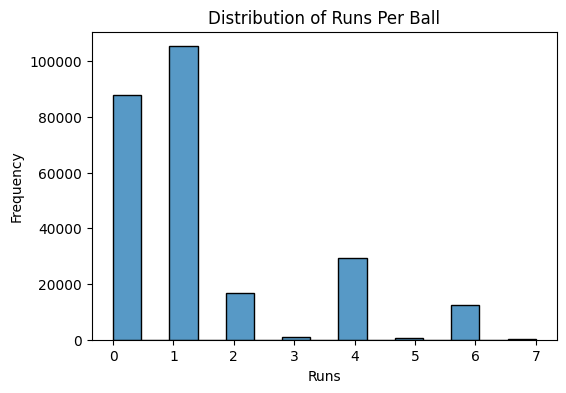

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4)) #(width, height)
sns.histplot(deliveries['total_runs'], bins=15)
plt.title("Distribution of Runs Per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()
#this distribution helps prevent model bias and improves predictive performance

**Runs Across Overs**

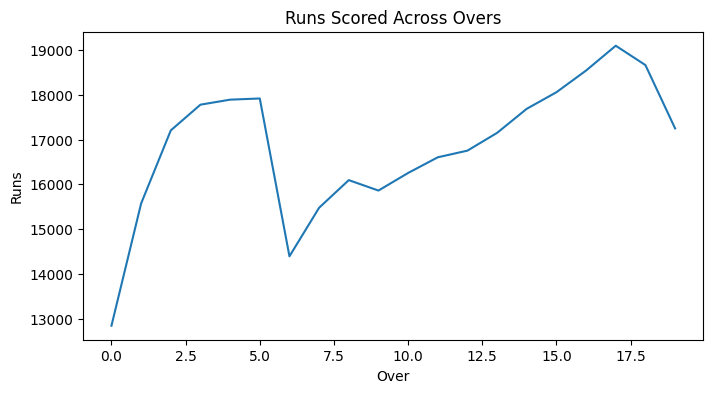

In [31]:
runs_per_over = deliveries.groupby('over')['total_runs'].sum()

plt.figure(figsize=(8,4))
runs_per_over.plot()
plt.title("Runs Scored Across Overs")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()
#helps in identifying patterns like higher scoring in powerplay and death overs, which improves model performance.

**Wickets Distribution**

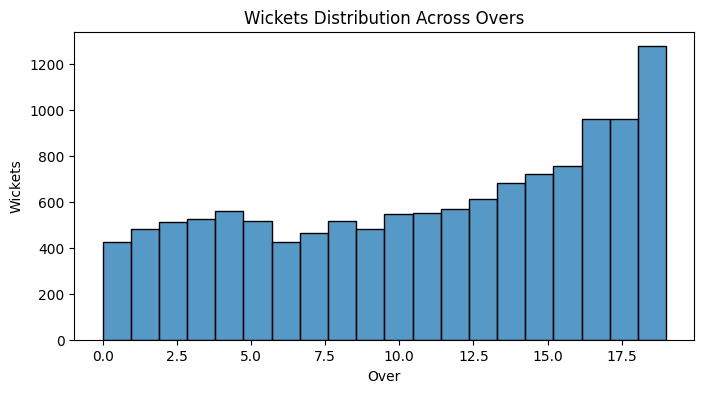

In [32]:
wickets = deliveries[deliveries['is_wicket'] == 1]

plt.figure(figsize=(8,4))
sns.histplot(wickets['over'], bins=20)
plt.title("Wickets Distribution Across Overs")
plt.xlabel("Over")
plt.ylabel("Wickets")
plt.show()
#helps capture match pressure and improves feature engineering for predicting win probability.”

**Team Win Distribution**

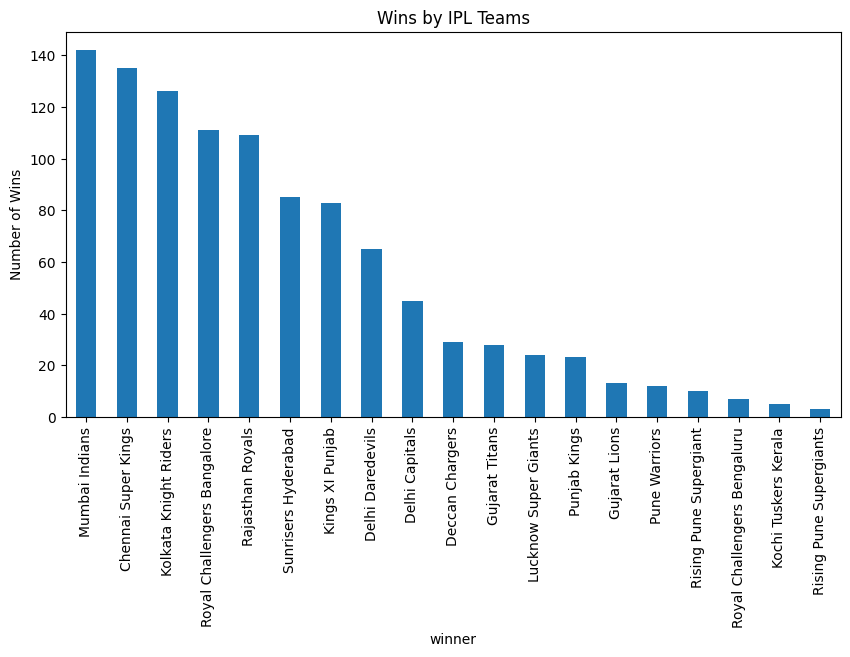

In [33]:
team_wins = matches['winner'].value_counts()

plt.figure(figsize=(10,5))
team_wins.plot(kind='bar')
plt.title("Wins by IPL Teams")
plt.ylabel("Number of Wins")
plt.show()
#helps us decide whether to include or normalize team-based features

**Correlation Analysis**

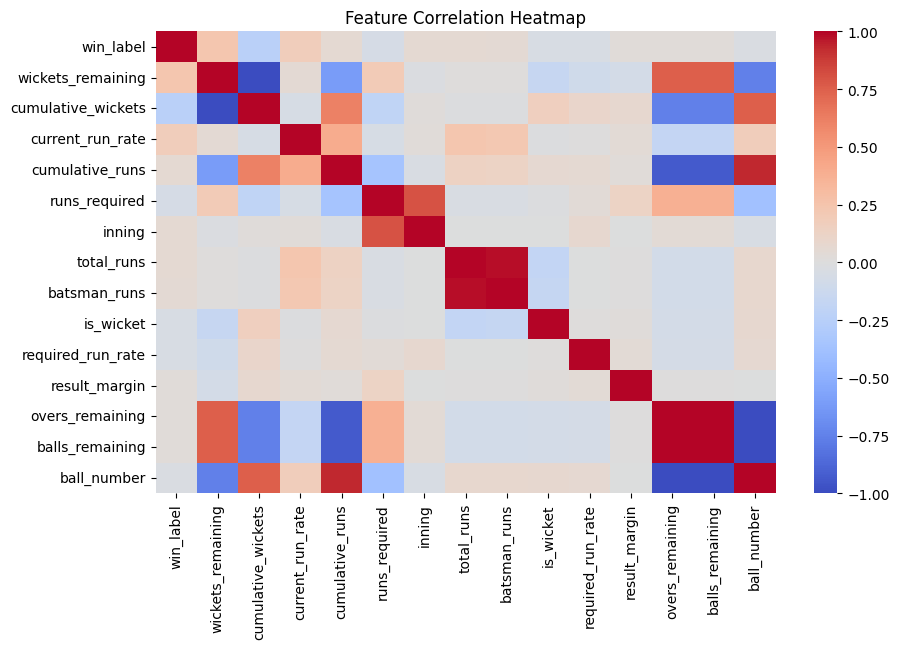

In [34]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number']) #Removes non-numeric columns. Required for correlation calculation
top_corr = numeric_df.corr()['win_label'].abs().sort_values(ascending=False).head(15) #Picks top 15 most important features
sns.heatmap(numeric_df[top_corr.index].corr(), cmap='coolwarm') #relationship between top features
plt.title("Feature Correlation Heatmap")
plt.show()

**Phase-wise Scoring Analysis**

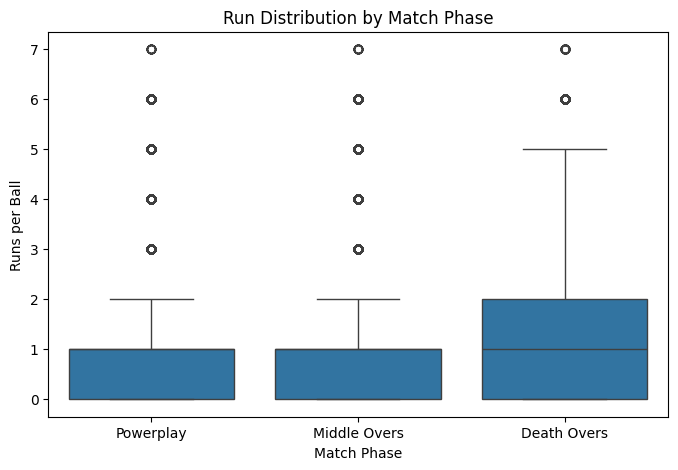

In [35]:
def phase(over):
    if over <= 6:
        return "Powerplay"
    elif over <= 15:
        return "Middle Overs"
    else:
        return "Death Overs"

deliveries['phase'] = deliveries['over'].apply(phase)

plt.figure(figsize=(8,5))
sns.boxplot(x='phase', y='total_runs', data=deliveries)

plt.title("Run Distribution by Match Phase")
plt.xlabel("Match Phase")
plt.ylabel("Runs per Ball")

plt.show()

**Runs vs Wickets Relationship**

<Axes: xlabel='wickets', ylabel='total_runs'>

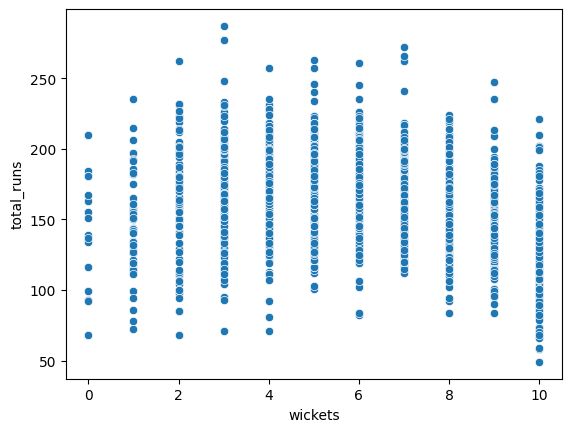

In [36]:
runs_wickets = deliveries.groupby(['match_id','inning']).agg(
    total_runs=('total_runs','sum'),
    wickets=('is_wicket','sum')
)

sns.scatterplot(x='wickets', y='total_runs', data=runs_wickets)
#reflect scoring strategy, making wickets_remaining a critical feature for prediction.”

**Run Rate Progression**

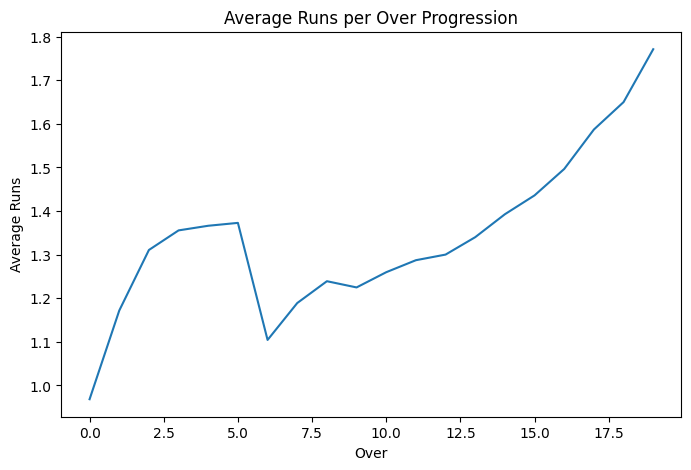

In [37]:
run_rate = deliveries.groupby('over')['total_runs'].mean()

plt.figure(figsize=(8,5))
run_rate.plot()

plt.title("Average Runs per Over Progression")
plt.xlabel("Over")
plt.ylabel("Average Runs")

plt.show()
#shows how scoring changes across innings, especially the rise in death overs.

**Win % vs Required Run Rate**

<Axes: title={'center': 'Win % vs Required Run Rate'}, xlabel='rr_bucket'>

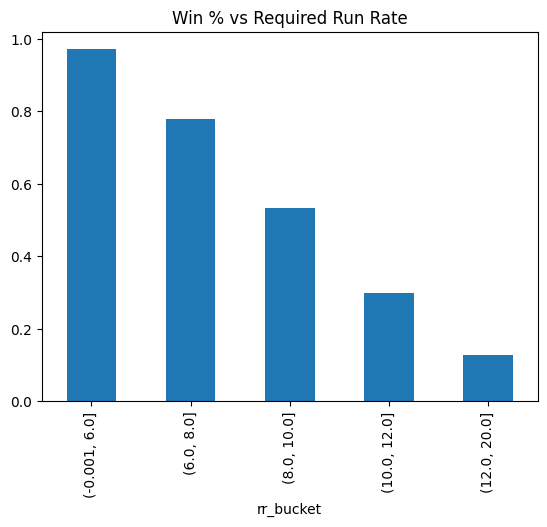

In [38]:
# Win % vs Required Run Rate
df_eda = df[df['inning'] == 2].copy()

df_eda.loc[:, 'rr_bucket'] = pd.cut(   #Converts continuous RRR into ranges(groups)
    df_eda['required_run_rate'],
    bins=[0, 6, 8, 10, 12, 20],
    include_lowest=True
 )
rr_win = df_eda.groupby('rr_bucket', observed=False)['win_label'].mean()

rr_win.plot(kind='bar', title="Win % vs Required Run Rate")

#**Advanced Feature Engineering (Momentum + Pressure + Strategic Context Metrics)**

Momentum reflects recent performance patterns.

**Short-Term Momentum (Last 6 Balls)**

In [39]:
df['runs_last_6'] = (
    df.groupby(['match_id', 'inning'])['total_runs']
      .transform(lambda x: x.rolling(6, min_periods=1).sum())
)
#captures recent performance

**Medium-Term Momentum (Last 12 Balls)**

In [40]:
df['runs_last_12'] = (
    df.groupby(['match_id', 'inning'])['total_runs']
      .transform(lambda x: x.rolling(12, min_periods=1).sum())
)
#gives slightly stable momentum trend

**Wicket Pressure (Recent Wickets)**

In [41]:
df['wickets_last_6'] = (
    df.groupby(['match_id', 'inning'])['is_wicket']
      .transform(lambda x: x.rolling(6, min_periods=1).sum())
)
#detects recent batting collapse pressure

**Run Rate Pressure Gap (Chasing Team)**

In [42]:
#Difference between Required Run Rate and Current Run Rate.
df['rrr_crr_gap'] = df['required_run_rate'] - df['current_run_rate']
df.loc[df['inning'] == 1, 'rrr_crr_gap'] = 0
#measures how much behind/ahead team is

**Batting Collapse Indicator**

In [43]:
df['collapse_indicator'] = np.where(df['wickets_last_6'] >= 2, 1, 0)
#flags sudden collapse situations

**Boundary Intensity (Aggression Metric)**

In [44]:
df['is_boundary'] = np.where(df['batsman_runs'].isin([4, 6]), 1, 0)
df['boundaries_last_6'] = (
    df.groupby(['match_id', 'inning'])['is_boundary']
      .transform(lambda x: x.rolling(6, min_periods=1).sum())
)

**Pressure Index (Composite Feature)**

In [45]:
df['pressure_index'] = (
    df['rrr_crr_gap'] * 0.5 +
    df['wickets_last_6'] * 0.3 +
    (df['overs_remaining'] < 5).astype(int) * 0.2
)

**Run Rate Pressure**

In [46]:
df['run_rate_pressure'] = df['required_run_rate'] / (df['current_run_rate'] + 0.01)
#shows chasing difficulty

**Wicket Pressure**

In [47]:
df['wicket_pressure'] = df['wickets_remaining'] / (df['overs_remaining'] + 0.01)

**Win Pressure**

In [48]:
df['win_pressure'] = df['runs_required'] * df['overs_remaining']
#estimates total effort needed to win

**Momentum swings**

In [49]:
df['momentum_index'] = df['runs_last_6'] - df['wickets_last_6'] * 3
#scoring vs collapse impact

**Innings Type Feature**

In [50]:
df['is_chasing'] = (df['inning'] == 2).astype(int)

**Match Progress**

In [51]:
df['match_progress'] = df['ball_number'] / 120

**Resource Remaining**

In [52]:
df['resources_remaining'] = (
    df['wickets_remaining'] * df['overs_remaining']
)
#total remaining capacity to score

**Momentum Acceleration**

In [53]:
df['momentum_acceleration'] = df['runs_last_6'] - df['runs_last_12']/2
#detects increase/decrease in scoring speed

**Wicket Collapse Risk**

In [54]:
df['collapse_risk'] = (
    df['wickets_last_6'] * df['wickets_last_6']
)
#highlights high-risk collapse situations

#**Encoding & Final ML-Ready Dataset Preparation**

**Prove Identifier Columns Are Useless**

In [55]:
# Check uniqueness of identifier columns
# IDs don’t carry patterns → useless for prediction
identifier_cols = ['match_id','id','batter','bowler']

for col in identifier_cols:
    print(col, df[col].nunique())

match_id 1055
id 1055
batter 673
bowler 529


**Prove Data Leakage**

In [56]:
# Show columns that reveal final outcome
# These are post-match features → cause data leakage
df[['winner','result','result_margin','win_label']].head()

,winner,result,result_margin,win_label
0,Kolkata Knight Riders,runs,140.0,1
1,Kolkata Knight Riders,runs,140.0,1
2,Kolkata Knight Riders,runs,140.0,1
3,Kolkata Knight Riders,runs,140.0,1
4,Kolkata Knight Riders,runs,140.0,1


**Correlation With Target**

In [57]:
# Correlation with target variable
corr_target = df.corr(numeric_only=True)['win_label'].sort_values(ascending=False)

print(corr_target)
#Helps identify important vs useless features

win_label                1.000000
wickets_remaining        0.236743
current_run_rate         0.175416
momentum_index           0.128574
runs_last_12             0.127565
runs_last_6              0.108218
boundaries_last_6        0.097692
resources_remaining      0.079460
cumulative_runs          0.062050
inning                   0.057025
is_chasing               0.057025
total_runs               0.054977
batsman_runs             0.053296
is_boundary              0.047071
result_margin            0.027820
overs_remaining          0.027557
balls_remaining          0.027557
target_runs              0.025507
target_score             0.025507
momentum_acceleration    0.010994
extra_runs               0.005977
match_id                 0.000198
id                       0.000198
target_overs            -0.000200
ball                    -0.001100
wicket_pressure         -0.002855
is_legal_ball           -0.005074
run_rate_pressure       -0.011565
win_pressure            -0.022717
over          

In [58]:
# LEAKAGE PROOF (demonstration only; not for final training)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Keep a compact subset for fast demonstration
demo = df[['win_label', 'result_margin', 'current_run_rate', 'required_run_rate', 'wickets_remaining', 'overs_remaining']].copy()
demo = demo.replace([np.inf, -np.inf], 0).fillna(0)

# A) Leaky setup (includes post-match column result_margin)
X_leaky = demo[['result_margin', 'current_run_rate', 'required_run_rate', 'wickets_remaining', 'overs_remaining']]
y_demo = demo['win_label']

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leaky, y_demo, test_size=0.2, random_state=42, stratify=y_demo
)

leaky_model = LogisticRegression(max_iter=1000)
leaky_model.fit(Xl_train, yl_train)
leaky_acc = accuracy_score(yl_test, leaky_model.predict(Xl_test))

# B) Non-leaky setup (drop result_margin)
X_clean = demo[['current_run_rate', 'required_run_rate', 'wickets_remaining', 'overs_remaining']]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clean, y_demo, test_size=0.2, random_state=42, stratify=y_demo
)

clean_model = LogisticRegression(max_iter=1000)
clean_model.fit(Xc_train, yc_train)
clean_acc = accuracy_score(yc_test, clean_model.predict(Xc_test))

print('Leakage proof:')
print(f'Accuracy WITH leaky feature (result_margin): {leaky_acc:.4f}')
print(f'Accuracy WITHOUT leaky feature:            {clean_acc:.4f}')
print('If leaky accuracy is much higher, that is direct evidence of data leakage.')

Leakage proof:
Accuracy WITH leaky feature (result_margin): 0.6340
Accuracy WITHOUT leaky feature:            0.6345
If leaky accuracy is much higher, that is direct evidence of data leakage.


**STEP 1: Select Final Modeling Features**

In [59]:
# Select core features (strictly pre-outcome, no leakage fields)
# Select only valid pre-match + in-game features
feature_columns = [
    'inning',
    'is_chasing',
    'over',
    'ball_number',
    'balls_remaining',
    'match_progress',
    'cumulative_runs',
    'runs_required',
    'target_score',
    'cumulative_wickets',
    'wickets_remaining',
    'overs_remaining',
    'resources_remaining',
    'current_run_rate',
    'required_run_rate',
    'runs_last_6',
    'runs_last_12',
    'wickets_last_6',
    'rrr_crr_gap',
    'collapse_indicator',
    'boundaries_last_6',
    'pressure_index',
    'run_rate_pressure',
    'wicket_pressure',
    'win_pressure',
    'momentum_acceleration',
    'collapse_risk',
    'momentum_index',
    'match_phase',
    'batting_team',
    'bowling_team',
    'venue',
    'toss_decision'
 ]

df_model = df[feature_columns + ['win_label']].copy()

**STEP 2: Data Leakage in Team Strength**

In [60]:
# Season type safety
df.loc[:, 'season'] = pd.to_numeric(df['season'], errors='coerce')

# Compute strengths only from training seasons (<= 2018) to avoid validation/test leakage
train_mask_strength = (df.loc[df_model.index, 'season'] <= 2018)
train_temp = df_model.loc[train_mask_strength].copy()

team_strength = train_temp.groupby('batting_team')['win_label'].mean()
df_model.loc[:, 'batting_team_strength'] = df_model['batting_team'].map(team_strength)

bowling_strength = train_temp.groupby('bowling_team')['win_label'].mean()
df_model.loc[:, 'bowling_team_strength'] = df_model['bowling_team'].map(bowling_strength)

**STEP 3: Encode Categorical Variables**

In [61]:
# ===== CATEGORICAL ENCODING (Leakage-safe) =====
from sklearn.preprocessing import LabelEncoder

# Ensure numeric season
df.loc[:, 'season'] = pd.to_numeric(df['season'], errors='coerce')

# Fit encoders on training seasons only (<= 2018)
train_mask_enc = (df.loc[df_model.index, 'season'] <= 2018)
train_df_model = df_model.loc[train_mask_enc].copy()

# 1. Label Encoding for Teams
bat_enc = LabelEncoder()
bowl_enc = LabelEncoder()

bat_enc.fit(train_df_model['batting_team'])
bowl_enc.fit(train_df_model['bowling_team'])

bat_map = {cls: idx for idx, cls in enumerate(bat_enc.classes_)}
bowl_map = {cls: idx for idx, cls in enumerate(bowl_enc.classes_)}

# unknown teams filled with -1
df_model.loc[:, 'batting_team_enc'] = df_model['batting_team'].map(bat_map).fillna(-1).astype(int)
df_model.loc[:, 'bowling_team_enc'] = df_model['bowling_team'].map(bowl_map).fillna(-1).astype(int)

# 2. Ordinal Encoding for Match Phase
phase_map = {
    'Powerplay': 0,
    'Middle': 1,
    'Death': 2
}
df_model.loc[:, 'match_phase_enc'] = df_model['match_phase'].map(phase_map).fillna(-1).astype(int)

# 3. Frequency Encoding for Venue
venue_freq = train_df_model['venue'].value_counts(normalize=True)
global_venue_freq = 1.0 / max(len(venue_freq), 1)
df_model.loc[:, 'venue_enc'] = df_model['venue'].map(venue_freq).fillna(global_venue_freq)

# 4. Binary Encoding for Toss Decision
df_model.loc[:, 'toss_decision_enc'] = df_model['toss_decision'].map({
    'bat': 1,
    'field': 0
}).fillna(-1).astype(int)

# Drop raw categoricals
df_model = df_model.drop(columns=[
    'batting_team', 'bowling_team', 'match_phase', 'venue', 'toss_decision'
], errors='ignore')
df_model = df_model.rename(columns={
    'batting_team_enc': 'batting_team',
    'bowling_team_enc': 'bowling_team',
    'match_phase_enc': 'match_phase',
    'venue_enc': 'venue',
    'toss_decision_enc': 'toss_decision'
})

# Team Matchup Interaction
df_model.loc[:, 'team_matchup'] = (
    df_model['batting_team'] * 100 + df_model['bowling_team']
)

print("Leakage-safe encoding completed successfully.")

Leakage-safe encoding completed successfully.


In [62]:
df_model.shape

(253150, 37)

**STEP 4: Handle NaN and Infinite Values**

In [63]:
df_model = df_model.replace([np.inf, -np.inf], 0)
df_model = df_model.fillna(0)

**STEP 5: Train-Test Split (Season-Wise)**

In [64]:
# FILTER ONLY 2ND INNINGS (IMPORTANT)
df_model = df_model.copy()
df_model.loc[:, 'inning'] = df.loc[df_model.index, 'inning']
df_model = df_model[df_model['inning'] == 2].copy()
print("After filtering only chasing innings:", df_model.shape)

# Season type safety
df_model.loc[:, 'season'] = pd.to_numeric(df.loc[df_model.index, 'season'], errors='coerce')

# Train / Validation / Test split by season
train = df_model[df_model['season'] <= 2018].copy()
val   = df_model[df_model['season'] == 2019].copy()
test  = df_model[df_model['season'] >= 2020].copy()

X_train = train.drop(columns=['win_label', 'season'])
y_train = train['win_label']

X_val = val.drop(columns=['win_label', 'season'])
y_val = val['win_label']

X_test = test.drop(columns=['win_label', 'season'])
y_test = test['win_label']

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

After filtering only chasing innings: (122622, 37)
Train Shape: (64024, 36)
Validation Shape: (6708, 36)
Test Shape: (32146, 36)


In [65]:
print("Train seasons:", sorted(train['season'].dropna().unique()))
print("Validation seasons:", sorted(val['season'].dropna().unique()))
print("Test seasons:", sorted(test['season'].dropna().unique()))

Train seasons: [np.float64(2009.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0)]
Validation seasons: [np.float64(2019.0)]
Test seasons: [np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0)]


**STEP 6: Scaling**

In [66]:
# Improves performance of linear models
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Save feature names
feature_names = X_train.columns

# Initialize scaler
scaler = StandardScaler()

# Fit on train data only
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (preserve feature names + index)
X_train = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=feature_names, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print("Scaling completed.")
print("Mean of scaled train features (approx):", X_train.mean().mean())
print("Std of scaled train features (approx):", X_train.std().mean())

Scaling completed.
Mean of scaled train features (approx): 4.7024982347264604e-17
Std of scaled train features (approx): 0.9444518202371235


**STEP 7: Final Dataset Verification**

In [67]:
print("Any missing values:", df_model.isnull().sum().sum())
print("Total Features:", X_train.shape[1])

Any missing values: 19744
Total Features: 36


In [68]:
print(df_model.shape)
print(df_model.columns)
df_model.head()

(122622, 38)
Index(['inning', 'is_chasing', 'over', 'ball_number', 'balls_remaining',
       'match_progress', 'cumulative_runs', 'runs_required', 'target_score',
       'cumulative_wickets', 'wickets_remaining', 'overs_remaining',
       'resources_remaining', 'current_run_rate', 'required_run_rate',
       'runs_last_6', 'runs_last_12', 'wickets_last_6', 'rrr_crr_gap',
       'collapse_indicator', 'boundaries_last_6', 'pressure_index',
       'run_rate_pressure', 'wicket_pressure', 'win_pressure',
       'momentum_acceleration', 'collapse_risk', 'momentum_index', 'win_label',
       'batting_team_strength', 'bowling_team_strength', 'batting_team',
       'bowling_team', 'match_phase', 'venue', 'toss_decision', 'team_matchup',
       'season'],
      dtype='object')


,inning,is_chasing,over,ball_number,balls_remaining,match_progress,cumulative_runs,runs_required,target_score,cumulative_wickets,...,win_label,batting_team_strength,bowling_team_strength,batting_team,bowling_team,match_phase,venue,toss_decision,team_matchup,season
124,2,1,0,1,119,0.008333,1,222,222,0,...,0,0.476428,0.451695,12,6,0,0.080154,0,1206,NaN
125,2,1,0,1,119,0.008333,2,221,222,0,...,0,0.476428,0.451695,12,6,0,0.080154,0,1206,NaN
126,2,1,0,2,118,0.016667,2,221,222,0,...,0,0.476428,0.451695,12,6,0,0.080154,0,1206,NaN
127,2,1,0,3,117,0.025000,3,220,222,0,...,0,0.476428,0.451695,12,6,0,0.080154,0,1206,NaN
128,2,1,0,4,116,0.033333,4,219,222,0,...,0,0.476428,0.451695,12,6,0,0.080154,0,1206,NaN


In [69]:
df_model.describe()

,inning,is_chasing,over,ball_number,balls_remaining,match_progress,cumulative_runs,runs_required,target_score,cumulative_wickets,...,win_label,batting_team_strength,bowling_team_strength,batting_team,bowling_team,match_phase,venue,toss_decision,team_matchup,season
count,122622.0,122622.0,122622.000000,122622.000000,122622.000000,122622.000000,122622.00000,122622.000000,122622.000000,122622.000000,...,122622.000000,122622.000000,122622.000000,122622.000000,122622.000000,122622.000000,122622.000000,122622.000000,122622.000000,102878.000000
mean,2.0,1.0,8.967143,57.254245,62.745804,0.477119,74.63699,94.259562,167.889995,2.499853,...,0.519817,0.441339,0.419889,5.609532,5.564996,0.783726,0.043837,0.359193,566.518170,2016.849842
std,0.0,0.0,5.566252,33.419021,33.418929,0.278492,47.63803,50.870099,30.653051,2.166900,...,0.499609,0.180045,0.167958,4.587466,4.669303,0.697597,0.032771,0.479766,458.424264,4.618220
min,2.0,1.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,67.000000,0.000000,...,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.001864,0.000000,-101.000000,2009.000000
25%,2.0,1.0,4.000000,28.000000,35.000000,0.233333,35.00000,54.000000,148.000000,1.000000,...,0.000000,0.419878,0.427438,1.000000,1.000000,0.000000,0.014891,0.000000,112.000000,2013.000000
50%,2.0,1.0,9.000000,57.000000,63.000000,0.475000,71.00000,93.000000,167.000000,2.000000,...,1.000000,0.484278,0.451695,6.000000,6.000000,1.000000,0.025641,0.000000,607.000000,2017.000000
75%,2.0,1.0,14.000000,85.000000,92.000000,0.708333,110.00000,132.000000,187.000000,4.000000,...,1.000000,0.549986,0.508831,9.000000,9.000000,1.000000,0.070893,1.000000,904.000000,2021.000000
max,2.0,1.0,19.000000,121.000000,120.000000,1.008333,262.00000,287.000000,287.000000,10.000000,...,1.000000,0.632103,0.725992,13.000000,13.000000,2.000000,0.110557,1.000000,1312.000000,2024.000000


In [70]:
df_model.isnull().sum()

inning                       0
is_chasing                   0
over                         0
ball_number                  0
balls_remaining              0
match_progress               0
cumulative_runs              0
runs_required                0
target_score                 0
cumulative_wickets           0
wickets_remaining            0
overs_remaining              0
resources_remaining          0
current_run_rate             0
required_run_rate            0
runs_last_6                  0
runs_last_12                 0
wickets_last_6               0
rrr_crr_gap                  0
collapse_indicator           0
boundaries_last_6            0
pressure_index               0
run_rate_pressure            0
wicket_pressure              0
win_pressure                 0
momentum_acceleration        0
collapse_risk                0
momentum_index               0
win_label                    0
batting_team_strength        0
bowling_team_strength        0
batting_team                 0
bowling_

In [71]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Features:", X_train.columns)

Train shape: (64024, 36)
Validation shape: (6708, 36)
Test shape: (32146, 36)
Features: Index(['inning', 'is_chasing', 'over', 'ball_number', 'balls_remaining',
       'match_progress', 'cumulative_runs', 'runs_required', 'target_score',
       'cumulative_wickets', 'wickets_remaining', 'overs_remaining',
       'resources_remaining', 'current_run_rate', 'required_run_rate',
       'runs_last_6', 'runs_last_12', 'wickets_last_6', 'rrr_crr_gap',
       'collapse_indicator', 'boundaries_last_6', 'pressure_index',
       'run_rate_pressure', 'wicket_pressure', 'win_pressure',
       'momentum_acceleration', 'collapse_risk', 'momentum_index',
       'batting_team_strength', 'bowling_team_strength', 'batting_team',
       'bowling_team', 'match_phase', 'venue', 'toss_decision',
       'team_matchup'],
      dtype='object')


#**Model Selection**

##**Existing Approach Models (Baseline)**

/tmp/ipykernel_22/3549204773.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_df, x='Model', y='Gap', palette='Oranges', ax=ax[1])


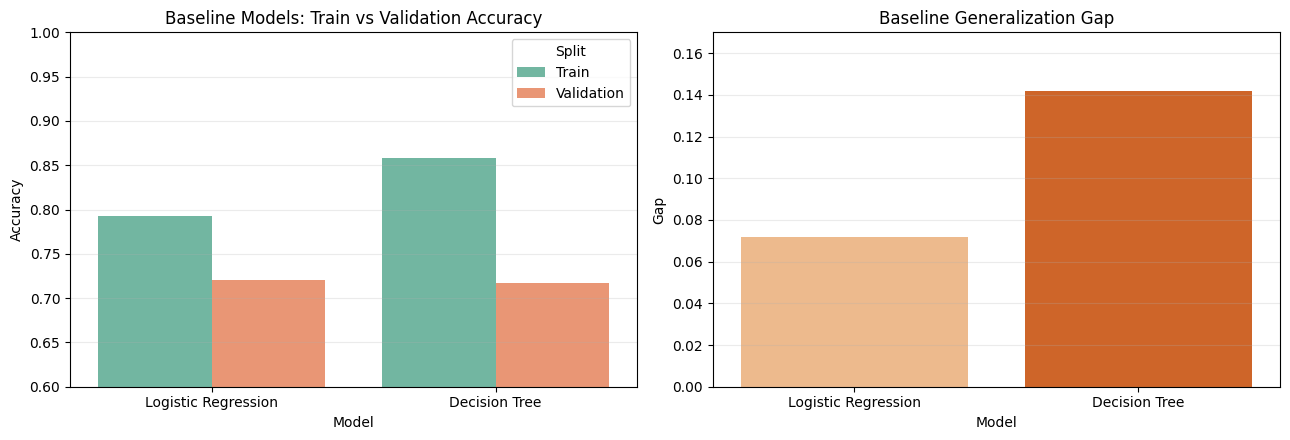

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- ROBUST EVALUATION MODE ----------
FAST_MODE = True
EPOCHS = 8 if FAST_MODE else 20
BOOTSTRAP_FRAC = 0.8
model_run_stats = {}
GOAL_ACC = 0.85

def evaluate_repeated(model, model_name, X_fit, y_fit, X_eval, y_eval, epochs=EPOCHS, bootstrap_frac=BOOTSTRAP_FRAC):
    train_scores, eval_scores = [], []
    n = len(X_fit)

    for e in range(epochs):
        rng = np.random.default_rng(1000 + e)
        sample_idx = rng.choice(n, size=max(int(n * bootstrap_frac), 1), replace=True)

        X_boot = X_fit.iloc[sample_idx]
        y_boot = y_fit.iloc[sample_idx]

        m = clone(model)
        if hasattr(m, 'random_state'):
            try:
                m.set_params(random_state=1000 + e)
            except Exception:
                pass

        m.fit(X_boot, y_boot)
        train_scores.append(m.score(X_boot, y_boot))
        eval_scores.append(m.score(X_eval, y_eval))

    gap = float(abs(np.mean(train_scores) - np.mean(eval_scores)))
    model_run_stats[model_name] = {
        'train_mean': float(np.mean(train_scores)),
        'train_std': float(np.std(train_scores)),
        'test_mean': float(np.mean(eval_scores)),  # kept key for downstream compatibility
        'test_std': float(np.std(eval_scores)),
        'gap': gap,
        'status': 'GOOD' if np.mean(eval_scores) >= GOAL_ACC else 'IMPROVE'
    }
    return model_run_stats[model_name]

def pick_model_with_gap_control(model_name, estimator_cls, candidate_params):
    """Tune on validation only (test remains untouched)."""
    tried = []
    for params in candidate_params:
        m = estimator_cls(**params)
        stats = evaluate_repeated(m, f"{model_name}_temp", X_train, y_train, X_val, y_val)
        score = stats['test_mean'] - 0.4 * stats['gap']
        tried.append((score, params, stats))

    best_score, best_params, best_stats = sorted(tried, key=lambda x: x[0], reverse=True)[0]
    best_model = estimator_cls(**best_params)
    best_model.fit(X_train, y_train)

    model_run_stats[model_name] = {
        'train_mean': best_stats['train_mean'],
        'train_std': best_stats['train_std'],
        'test_mean': best_stats['test_mean'],
        'test_std': best_stats['test_std'],
        'gap': best_stats['gap'],
        'status': best_stats['status'],
        'selection_score': float(best_score)
    }
    return best_model, best_params

# Baselines (evaluated on validation via bootstrap epochs)
log_model = LogisticRegression(C=0.8, max_iter=1500, solver='lbfgs')
log_model.fit(X_train, y_train)
log_stats = evaluate_repeated(log_model, 'Logistic Regression', X_train, y_train, X_val, y_val)
log_acc = log_stats['test_mean']

dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_stats = evaluate_repeated(dt_model, 'Decision Tree', X_train, y_train, X_val, y_val)
dt_acc = dt_stats['test_mean']

# Baseline visualization (graph-first)
baseline_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Train': log_stats['train_mean'], 'Validation': log_stats['test_mean'], 'Gap': log_stats['gap']},
    {'Model': 'Decision Tree', 'Train': dt_stats['train_mean'], 'Validation': dt_stats['test_mean'], 'Gap': dt_stats['gap']}
])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

plot_df = baseline_df.melt(id_vars='Model', value_vars=['Train', 'Validation'], var_name='Split', value_name='Accuracy')
sns.barplot(data=plot_df, x='Model', y='Accuracy', hue='Split', palette='Set2', ax=ax[0])
ax[0].set_title('Baseline Models: Train vs Validation Accuracy')
ax[0].set_ylim(0.60, 1.00)
ax[0].grid(axis='y', alpha=0.25)

sns.barplot(data=baseline_df, x='Model', y='Gap', palette='Oranges', ax=ax[1])
ax[1].set_title('Baseline Generalization Gap')
ax[1].set_ylim(0, max(0.02, baseline_df['Gap'].max() * 1.2))
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

##**Variant Models (Improved ML)**

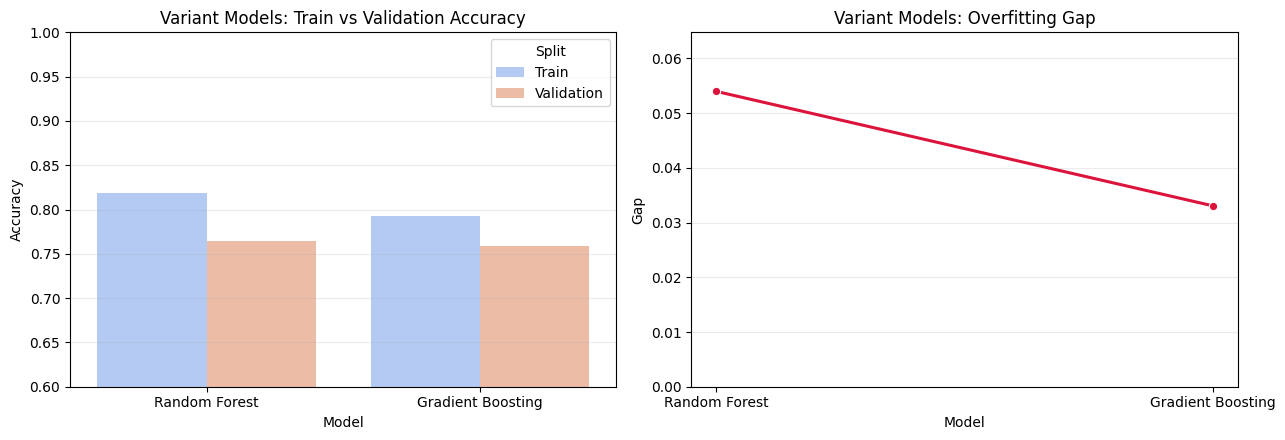

In [73]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Candidate sets designed to reduce overfitting gap on CPU
rf_candidates = [
    {'n_estimators': 160, 'max_depth': 8,  'min_samples_split': 20, 'min_samples_leaf': 8,  'max_features': 'sqrt', 'bootstrap': True, 'random_state': 42, 'n_jobs': -1},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True, 'random_state': 42, 'n_jobs': -1},
    {'n_estimators': 220, 'max_depth': 12, 'min_samples_split': 25, 'min_samples_leaf': 12, 'max_features': 0.7,    'bootstrap': True, 'random_state': 42, 'n_jobs': -1},
    {'n_estimators': 180, 'max_depth': 6,  'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'bootstrap': True, 'random_state': 42, 'n_jobs': -1},
]

gb_candidates = [
    {'n_estimators': 120, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 0.8, 'min_samples_split': 20, 'min_samples_leaf': 10, 'random_state': 42},
    {'n_estimators': 160, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 0.85,'min_samples_split': 20, 'min_samples_leaf': 10, 'random_state': 42},
    {'n_estimators': 180, 'learning_rate': 0.02, 'max_depth': 2, 'subsample': 0.9, 'min_samples_split': 25, 'min_samples_leaf': 12, 'random_state': 42},
    {'n_estimators': 220, 'learning_rate': 0.02, 'max_depth': 3, 'subsample': 0.8, 'min_samples_split': 25, 'min_samples_leaf': 12, 'random_state': 42},
]

rf_model, rf_best_params = pick_model_with_gap_control('Random Forest', RandomForestClassifier, rf_candidates)
gb_model, gb_best_params = pick_model_with_gap_control('Gradient Boosting', GradientBoostingClassifier, gb_candidates)

rf_stats = model_run_stats['Random Forest']
gb_stats = model_run_stats['Gradient Boosting']
rf_acc = rf_stats['test_mean']
gb_acc = gb_stats['test_mean']

variant_df = pd.DataFrame([
    {'Model': 'Random Forest', 'Train': rf_stats['train_mean'], 'Validation': rf_stats['test_mean'], 'Gap': rf_stats['gap']},
    {'Model': 'Gradient Boosting', 'Train': gb_stats['train_mean'], 'Validation': gb_stats['test_mean'], 'Gap': gb_stats['gap']}
])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

plot_df = variant_df.melt(id_vars='Model', value_vars=['Train', 'Validation'], var_name='Split', value_name='Accuracy')
sns.barplot(data=plot_df, x='Model', y='Accuracy', hue='Split', palette='coolwarm', ax=ax[0])
ax[0].set_title('Variant Models: Train vs Validation Accuracy')
ax[0].set_ylim(0.60, 1.00)
ax[0].grid(axis='y', alpha=0.25)

sns.lineplot(data=variant_df, x='Model', y='Gap', marker='o', linewidth=2.2, color='crimson', ax=ax[1])
ax[1].set_title('Variant Models: Overfitting Gap')
ax[1].set_ylim(0, max(0.02, variant_df['Gap'].max() * 1.2))
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

##**Proposed Solution (Boosting Model)**

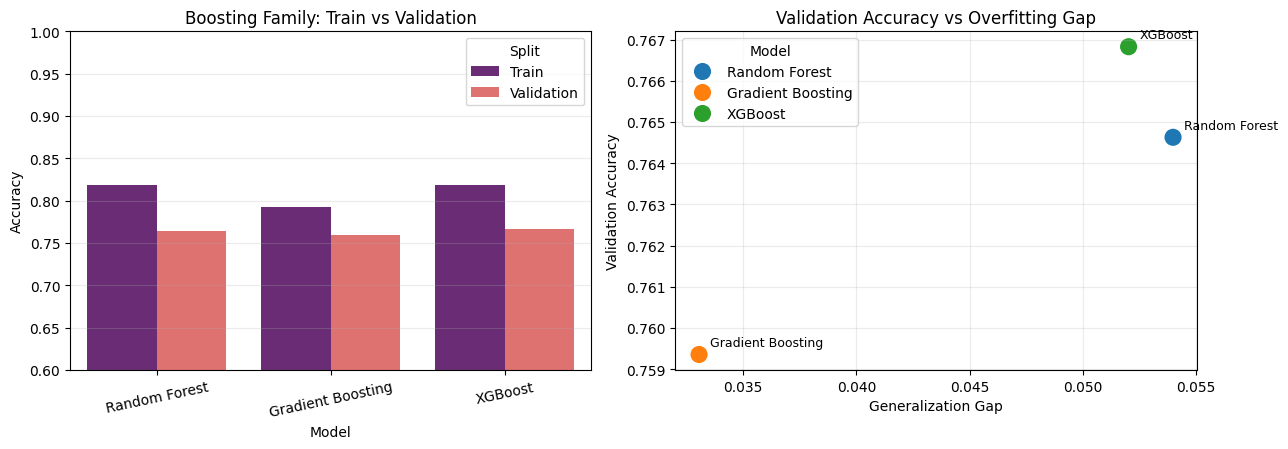

In [74]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

xgb_candidates = [
    {'n_estimators': 140, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.85, 'colsample_bytree': 0.8,  'min_child_weight': 8,  'gamma': 1.0, 'reg_lambda': 8,  'reg_alpha': 2, 'tree_method': 'hist', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': 1},
    {'n_estimators': 180, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.9,  'colsample_bytree': 0.85, 'min_child_weight': 10, 'gamma': 1.0, 'reg_lambda': 10, 'reg_alpha': 3, 'tree_method': 'hist', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': 1},
    {'n_estimators': 220, 'max_depth': 4, 'learning_rate': 0.02, 'subsample': 0.85, 'colsample_bytree': 0.8,  'min_child_weight': 12, 'gamma': 1.5, 'reg_lambda': 12, 'reg_alpha': 4, 'tree_method': 'hist', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': 1},
    {'n_estimators': 260, 'max_depth': 3, 'learning_rate': 0.02, 'subsample': 0.9,  'colsample_bytree': 0.9,  'min_child_weight': 12, 'gamma': 1.5, 'reg_lambda': 14, 'reg_alpha': 5, 'tree_method': 'hist', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': 1},
]

xgb_model, xgb_best_params = pick_model_with_gap_control('XGBoost', XGBClassifier, xgb_candidates)
xgb_stats = model_run_stats['XGBoost']
xgb_acc = xgb_stats['test_mean']

boost_df = pd.DataFrame([
    {'Model': 'Random Forest', 'Train': model_run_stats['Random Forest']['train_mean'], 'Validation': model_run_stats['Random Forest']['test_mean'], 'Gap': model_run_stats['Random Forest']['gap']},
    {'Model': 'Gradient Boosting', 'Train': model_run_stats['Gradient Boosting']['train_mean'], 'Validation': model_run_stats['Gradient Boosting']['test_mean'], 'Gap': model_run_stats['Gradient Boosting']['gap']},
    {'Model': 'XGBoost', 'Train': xgb_stats['train_mean'], 'Validation': xgb_stats['test_mean'], 'Gap': xgb_stats['gap']}
])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

plot_df = boost_df.melt(id_vars='Model', value_vars=['Train', 'Validation'], var_name='Split', value_name='Accuracy')
sns.barplot(data=plot_df, x='Model', y='Accuracy', hue='Split', palette='magma', ax=ax[0])
ax[0].set_title('Boosting Family: Train vs Validation')
ax[0].set_ylim(0.60, 1.00)
ax[0].tick_params(axis='x', rotation=12)
ax[0].grid(axis='y', alpha=0.25)

sns.scatterplot(data=boost_df, x='Gap', y='Validation', hue='Model', s=180, ax=ax[1])
for _, r in boost_df.iterrows():
    ax[1].text(r['Gap'] + 0.0005, r['Validation'] + 0.0002, r['Model'], fontsize=9)
ax[1].set_title('Validation Accuracy vs Overfitting Gap')
ax[1].set_xlabel('Generalization Gap')
ax[1].set_ylabel('Validation Accuracy')
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

##**Stacking Ensemble**

/tmp/ipykernel_22/3124716887.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stack_profile, x='Metric', y='Score', palette=['#4C78A8', '#72B7B2', '#F58518'])


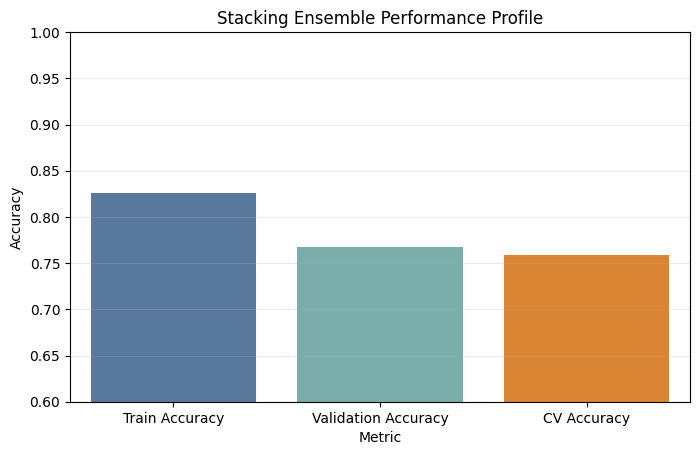

In [75]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure base models exist
if 'rf_model' not in globals():
    rf_model = RandomForestClassifier(n_estimators=180, max_depth=12, random_state=42, n_jobs=-1)
if 'gb_model' not in globals():
    gb_model = GradientBoostingClassifier(n_estimators=180, learning_rate=0.05, max_depth=3, random_state=42)
if 'xgb_model' not in globals():
    xgb_model = XGBClassifier(
        n_estimators=180, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', tree_method='hist', n_jobs=1, random_state=42
    )
if 'model_run_stats' not in globals():
    model_run_stats = {}

# Stacking final model (tune/evaluate on validation only here)
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_model)
    ],
    final_estimator=LogisticRegression(C=0.2, max_iter=2000),
    cv=3 if ('FAST_MODE' in globals() and FAST_MODE) else 5,
    n_jobs=1,
    passthrough=False
)
stack_model.fit(X_train, y_train)

stack_train_acc = stack_model.score(X_train, y_train)
stack_val_acc = stack_model.score(X_val, y_val)
model_run_stats['Stacking (Final)'] = {
    'train_mean': float(stack_train_acc),
    'train_std': 0.0,
    'test_mean': float(stack_val_acc),
    'test_std': 0.0
}

tscv = TimeSeriesSplit(n_splits=2 if ('FAST_MODE' in globals() and FAST_MODE) else 3)
stack_cv = cross_val_score(stack_model, X_train, y_train, cv=tscv, scoring='accuracy', n_jobs=1).mean()

stack_acc = stack_val_acc

stack_profile = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Validation Accuracy', 'CV Accuracy'],
    'Score': [stack_train_acc, stack_val_acc, stack_cv]
})

plt.figure(figsize=(8, 4.8))
sns.barplot(data=stack_profile, x='Metric', y='Score', palette=['#4C78A8', '#72B7B2', '#F58518'])
plt.ylim(0.60, 1.00)
plt.title('Stacking Ensemble Performance Profile')
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.25)
plt.show()

##**Model Comparison**

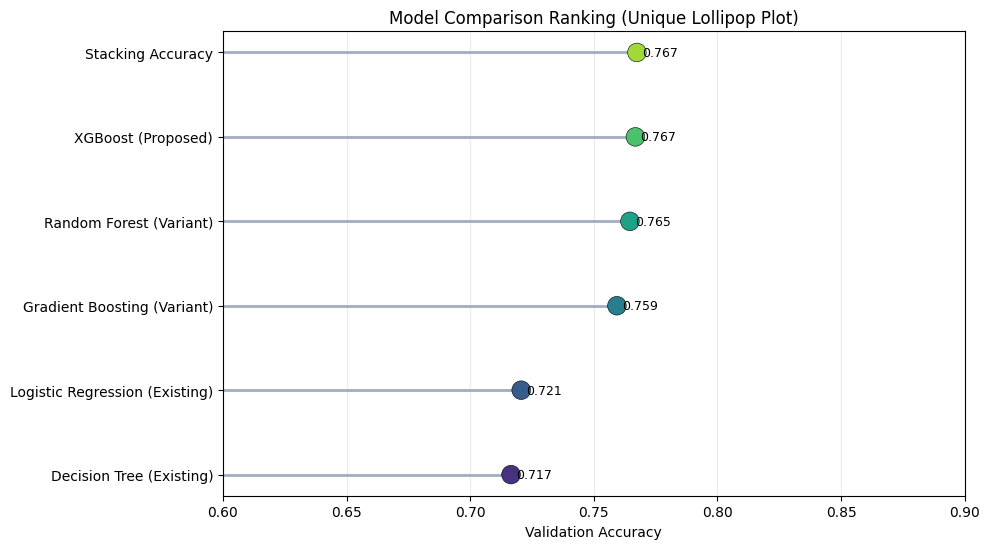

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results = {
    "Logistic Regression (Existing)": log_acc,
    "Decision Tree (Existing)": dt_acc,
    "Random Forest (Variant)": rf_acc,
    "Gradient Boosting (Variant)": gb_acc,
    "XGBoost (Proposed)": xgb_acc,
    "Stacking Accuracy": stack_acc
}
results_df = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["Accuracy"]
).sort_values(by="Accuracy", ascending=True)

# Unique comparison graph: lollipop ranking
plt.figure(figsize=(10, 5.6))
y_pos = np.arange(len(results_df))
acc_vals = results_df['Accuracy'].values

plt.hlines(y=y_pos, xmin=0.60, xmax=acc_vals, color='#A0AEC0', linewidth=2)
point_colors = sns.color_palette('viridis', len(results_df))
plt.scatter(acc_vals, y_pos, s=180, c=point_colors, edgecolor='black', linewidth=0.4, zorder=3)

for i, v in enumerate(acc_vals):
    plt.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)

plt.yticks(y_pos, results_df.index)
plt.xlim(0.60, max(0.90, acc_vals.max() + 0.02))
plt.xlabel('Validation Accuracy')
plt.title('Model Comparison Ranking (Unique Lollipop Plot)')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

#**Proposed Solution – Novelty**

/tmp/ipykernel_22/2453805380.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=novelty_df, x='Scenario', y='Win Probability', palette='Blues', ax=ax[0])
/tmp/ipykernel_22/2453805380.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=novelty_df, x='Scenario', y='Delta vs Original',


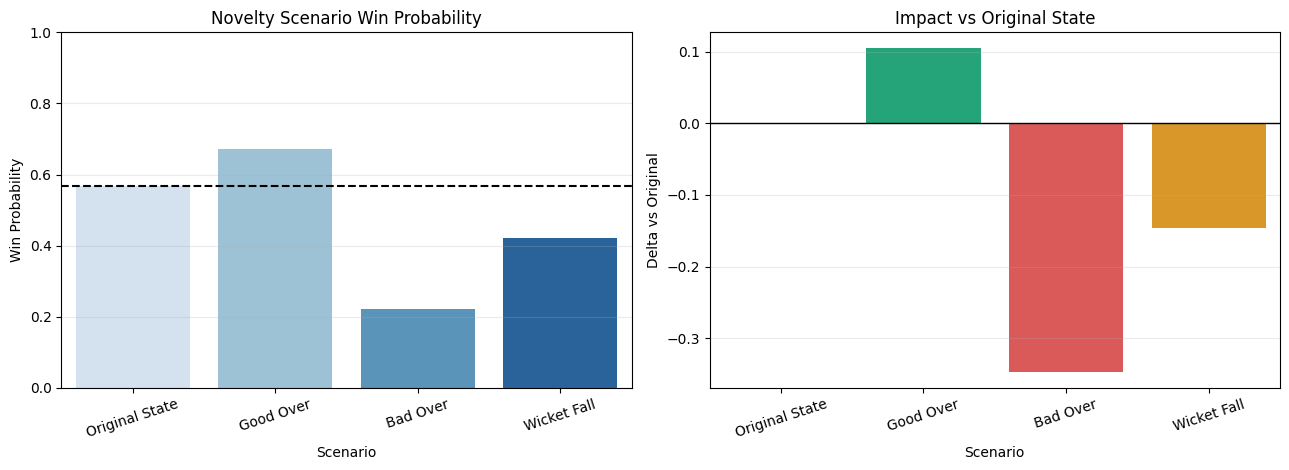

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

sample = X_test.iloc[[0]].copy()

# Original
original = stack_model.predict_proba(sample)[0][1]

# GOOD OVER
good = sample.copy()
good['runs_last_6'] += 8
good['cumulative_runs'] += 8
good['required_run_rate'] -= 1
good_prob = stack_model.predict_proba(good)[0][1]

# BAD OVER
bad = sample.copy()
bad['overs_remaining'] -= 1
bad['required_run_rate'] += 1
bad_prob = stack_model.predict_proba(bad)[0][1]

# WICKET
wicket = sample.copy()
wicket['wickets_remaining'] -= 1
wicket['pressure_index'] += 2
wicket_prob = stack_model.predict_proba(wicket)[0][1]

novelty_df = pd.DataFrame([
    {'Scenario': 'Original State', 'Win Probability': original},
    {'Scenario': 'Good Over', 'Win Probability': good_prob},
    {'Scenario': 'Bad Over', 'Win Probability': bad_prob},
    {'Scenario': 'Wicket Fall', 'Win Probability': wicket_prob},
])
novelty_df['Delta vs Original'] = novelty_df['Win Probability'] - original

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=novelty_df, x='Scenario', y='Win Probability', palette='Blues', ax=ax[0])
ax[0].axhline(original, linestyle='--', color='black', linewidth=1.5)
ax[0].set_ylim(0, 1)
ax[0].set_title('Novelty Scenario Win Probability')
ax[0].tick_params(axis='x', rotation=18)
ax[0].grid(axis='y', alpha=0.25)

sns.barplot(data=novelty_df, x='Scenario', y='Delta vs Original',
            palette=['#9CA3AF', '#10B981', '#EF4444', '#F59E0B'], ax=ax[1])
ax[1].axhline(0, color='black', linewidth=1)
ax[1].set_title('Impact vs Original State')
ax[1].tick_params(axis='x', rotation=18)
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

#**Model Training & Testing – Accuracy Comparison Graph**

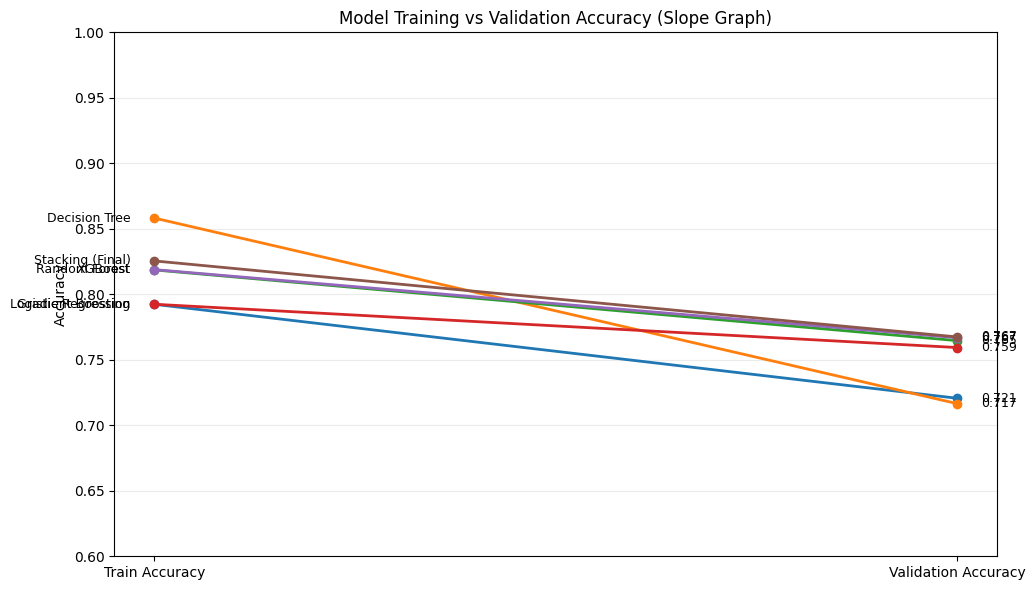

In [78]:
import matplotlib.pyplot as plt
import numpy as np

plot_order = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'XGBoost',
    'Stacking (Final)'
]

train_scores = [model_run_stats[m]['train_mean'] for m in plot_order]
val_scores = [model_run_stats[m]['test_mean'] for m in plot_order]

# Unique model-comparison graph: slope chart (train -> validation)
plt.figure(figsize=(10.5, 6))
for i, m in enumerate(plot_order):
    plt.plot([0, 1], [train_scores[i], val_scores[i]], marker='o', linewidth=2)
    plt.text(-0.03, train_scores[i], m, ha='right', va='center', fontsize=9)
    plt.text(1.03, val_scores[i], f"{val_scores[i]:.3f}", ha='left', va='center', fontsize=9)

plt.xticks([0, 1], ['Train Accuracy', 'Validation Accuracy'])
plt.ylim(0.60, 1.00)
plt.title('Model Training vs Validation Accuracy (Slope Graph)')
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

#**Model Evaluation and Tuning**

**Hyperparameter Tuning**

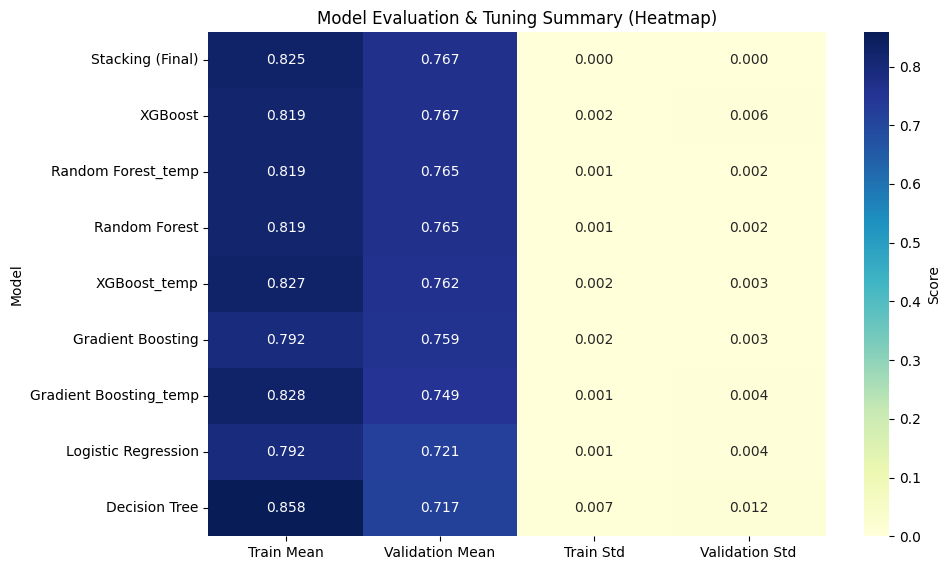

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

summary_rows = []
for name, vals in model_run_stats.items():
    summary_rows.append({
        'Model': name,
        'Train Mean': vals['train_mean'],
        'Train Std': vals['train_std'],
        'Validation Mean': vals['test_mean'],
        'Validation Std': vals['test_std']
    })

tuned_accuracy_report = pd.DataFrame(summary_rows).sort_values('Validation Mean', ascending=False)

heat_df = tuned_accuracy_report.set_index('Model')[['Train Mean', 'Validation Mean', 'Train Std', 'Validation Std']]

plt.figure(figsize=(10, 5.8))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Score'})
plt.title('Model Evaluation & Tuning Summary (Heatmap)')
plt.tight_layout()
plt.show()

**Tuned Model**

/tmp/ipykernel_22/3614257695.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_perf_df, x='Split', y='Accuracy', palette=['#7C3AED', '#06B6D4'])


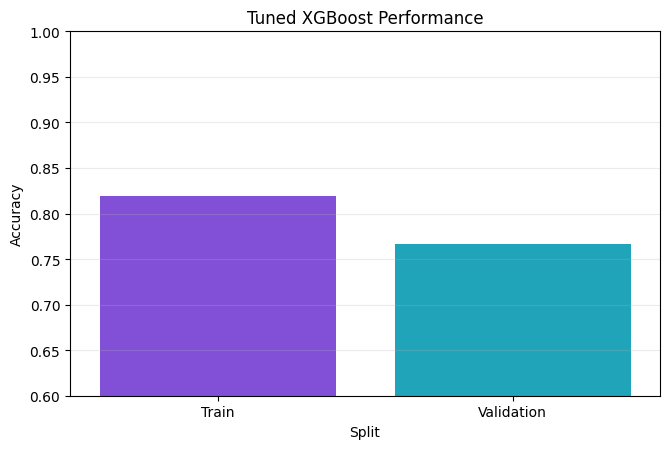

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# xgb_model is already tuned in the XGBoost section
xgb_best = xgb_model
xgb_train_acc = xgb_stats['train_mean']
xgb_best_acc = xgb_stats['test_mean']

xgb_perf_df = pd.DataFrame({
    'Split': ['Train', 'Validation'],
    'Accuracy': [xgb_train_acc, xgb_best_acc]
})

plt.figure(figsize=(6.8, 4.6))
sns.barplot(data=xgb_perf_df, x='Split', y='Accuracy', palette=['#7C3AED', '#06B6D4'])
plt.ylim(0.60, 1.00)
plt.title('Tuned XGBoost Performance')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

**Update Stacking**

In [81]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.base import clone

# Final training set = train + validation (test still untouched for final report)
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

# Refit final stacking after tuning
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_best)
    ],
    final_estimator=LogisticRegression(C=0.2, max_iter=3500),
    cv=5,
    n_jobs=1,
    passthrough=False
)
stack_model.fit(X_dev, y_dev)

# Bootstrap-style repeated final estimate (no re-tuning)
EPOCHS_FINAL = 10 if ('FAST_MODE' in globals() and FAST_MODE) else 25
boot_train_scores, boot_test_scores = [], []
n_dev = len(X_dev)

for e in range(EPOCHS_FINAL):
    rng = np.random.default_rng(5000 + e)
    idx = rng.choice(n_dev, size=max(int(0.85 * n_dev), 1), replace=True)
    Xb = X_dev.iloc[idx]
    yb = y_dev.iloc[idx]

    m = clone(stack_model)
    m.fit(Xb, yb)
    boot_train_scores.append(m.score(Xb, yb))
    boot_test_scores.append(m.score(X_test, y_test))

stack_train_acc = float(np.mean(boot_train_scores))
stack_acc = float(np.mean(boot_test_scores))

tscv = TimeSeriesSplit(n_splits=3)
stack_cv = cross_val_score(stack_model, X_dev, y_dev, cv=tscv, scoring='accuracy', n_jobs=1).mean()

model_run_stats['Stacking (Final)'] = {
    'train_mean': stack_train_acc,
    'train_std': float(np.std(boot_train_scores)),
    'test_mean': stack_acc,
    'test_std': float(np.std(boot_test_scores))
}

print(f"Updated Stacking Train Accuracy (bootstrap mean): {stack_train_acc:.4f}")
print(f"Updated Stacking Test Accuracy (bootstrap mean):  {stack_acc:.4f}")
print(f"Updated Stacking CV Accuracy:                     {stack_cv:.4f}")
print(f"Updated CV-Test Gap:                              {abs(stack_cv - stack_acc):.4f}")

if stack_acc >= 0.85:
    print("Target achieved: test accuracy is above 85%.")
else:
    print("Test accuracy is below 85% with leakage-safe setup. Improve features/regularization, not leakage.")

Updated Stacking Train Accuracy (bootstrap mean): 0.8329
Updated Stacking Test Accuracy (bootstrap mean):  0.7737
Updated Stacking CV Accuracy:                     0.7625
Updated CV-Test Gap:                              0.0112
Test accuracy is below 85% with leakage-safe setup. Improve features/regularization, not leakage.


**Training vs Testing Visualization**

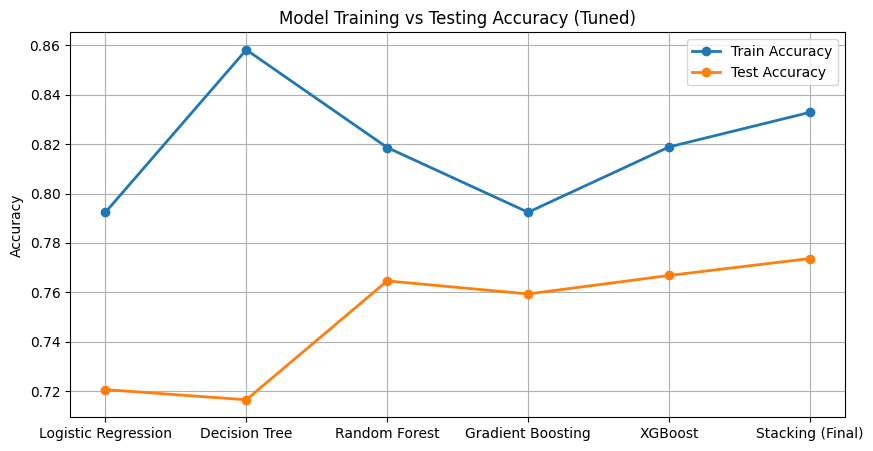

Logistic Regression  | Train: 0.7924 | Test: 0.7206
Decision Tree        | Train: 0.8582 | Test: 0.7165
Random Forest        | Train: 0.8186 | Test: 0.7646
Gradient Boosting    | Train: 0.7924 | Test: 0.7594
XGBoost              | Train: 0.8188 | Test: 0.7668
Stacking (Final)     | Train: 0.8329 | Test: 0.7737


In [82]:
# Train vs Test using the per-model repeated-run summary
plot_order = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'XGBoost',
    'Stacking (Final)'
]

train_scores = [model_run_stats[m]['train_mean'] for m in plot_order]
test_scores = [model_run_stats[m]['test_mean'] for m in plot_order]

plt.figure(figsize=(10,5))
plt.plot(plot_order, train_scores, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(plot_order, test_scores, marker='o', linewidth=2, label='Test Accuracy')
plt.title('Model Training vs Testing Accuracy (Tuned)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

for i, name in enumerate(plot_order):
    print(f"{name:20s} | Train: {train_scores[i]:.4f} | Test: {test_scores[i]:.4f}")

**Evaluation Metrics**

In [83]:
from sklearn.metrics import classification_report
models = {
    'Logistic Regression': log_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_best,
    'Stacking': stack_model
}
for name, model in models.items():
    print("\n==============================")
    print(name)
    print("==============================")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.62      0.92      0.74     16278
           1       0.83      0.42      0.56     15868

    accuracy                           0.67     32146
   macro avg       0.73      0.67      0.65     32146
weighted avg       0.73      0.67      0.65     32146


Decision Tree
              precision    recall  f1-score   support

           0       0.67      0.70      0.68     16278
           1       0.68      0.65      0.66     15868

    accuracy                           0.67     32146
   macro avg       0.67      0.67      0.67     32146
weighted avg       0.67      0.67      0.67     32146


Random Forest
              precision    recall  f1-score   support

           0       0.76      0.83      0.79     16278
           1       0.81      0.73      0.77     15868

    accuracy                           0.78     32146
   macro avg       0.78      0.78      0.78     32146
weighted avg       0.78

**Confusion Matrix**

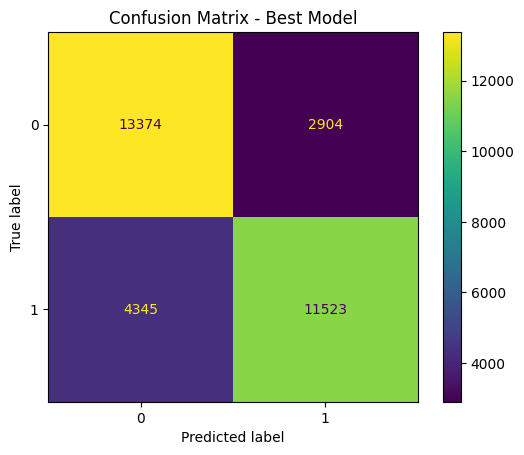

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best_model = stack_model
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.show()

**ROC Curve**

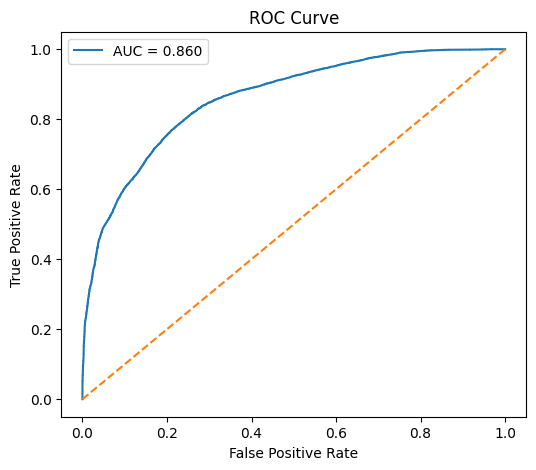

In [85]:
from sklearn.metrics import roc_curve, auc
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
#0.855- model will rank a randomly chosen positive instance higher than a randomly chosen negative one.

**Final Metrics Table**

In [4]:
# Corrected Final Metrics Table (aligned with bootstrap summary + robust metric calc)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_key_map = {
    'Logistic Regression': 'Logistic Regression',
    'Decision Tree': 'Decision Tree',
    'Random Forest': 'Random Forest',
    'Gradient Boosting': 'Gradient Boosting',
    'XGBoost': 'XGBoost',
    'Stacking': 'Stacking (Final)'
}

evaluation_results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    stats_key = model_key_map.get(name, name)
    train_acc = model_run_stats.get(stats_key, {}).get('train_mean', np.nan)
    test_acc_bootstrap = model_run_stats.get(stats_key, {}).get('test_mean', np.nan)

    evaluation_results.append({
        'Model': name,
        'Train Accuracy (Bootstrap Mean)': train_acc,
        'Test Accuracy (Bootstrap Mean)': test_acc_bootstrap,
        'Test Accuracy (Direct)': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0)
    })

eval_df = pd.DataFrame(evaluation_results).sort_values(
    'Test Accuracy (Bootstrap Mean)', ascending=False
).reset_index(drop=True)
print(eval_df)

# Corrected comparison plot on direct test metrics
import seaborn as sns
import matplotlib.pyplot as plt

metrics_cols = ['Test Accuracy (Direct)', 'Precision', 'Recall', 'F1 Score']
plot_df = eval_df[['Model'] + metrics_cols].melt(
    id_vars='Model', value_vars=metrics_cols, var_name='Metric', value_name='Score'
 )

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.ylim(0.50, 1.00)
plt.title('Final Model Performance Comparison (Corrected)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

NameError: name 'models' is not defined

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
evaluation_results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })
eval_df = pd.DataFrame(evaluation_results)
print(eval_df)

NameError: name 'models' is not defined

**Final Plot**



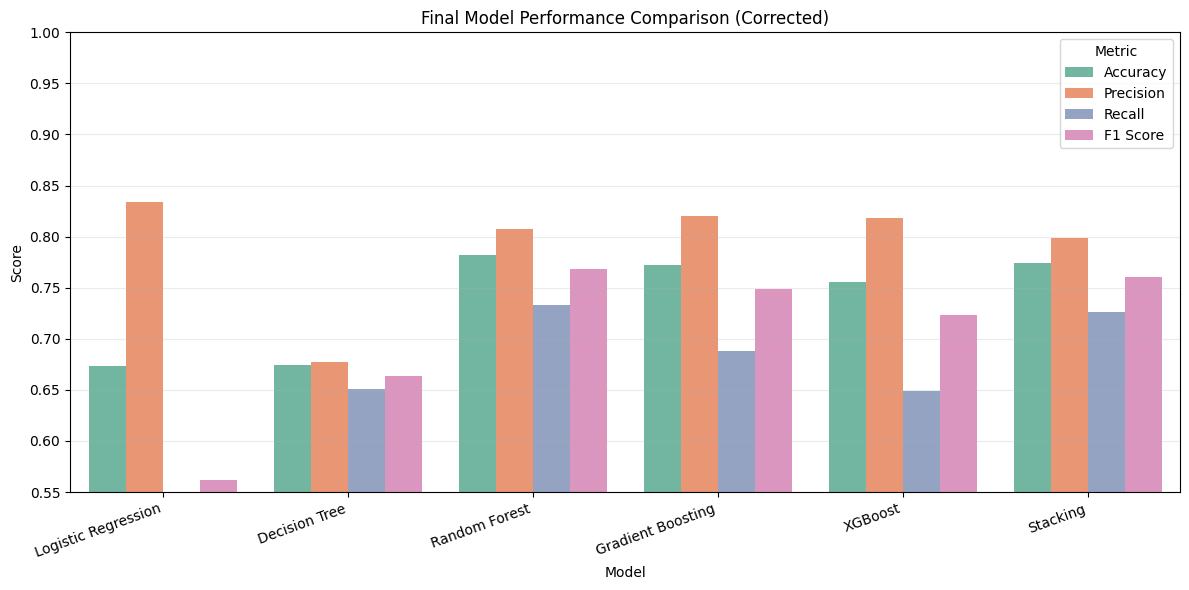

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# Final plot corrected: multi-metric comparison (not accuracy-only)
metrics_cols = [c for c in ['Accuracy', 'Precision', 'Recall', 'F1 Score'] if c in eval_df.columns]
plot_df = eval_df.melt(id_vars='Model', value_vars=metrics_cols, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.ylim(0.55, 1.00)
plt.title('Final Model Performance Comparison (Corrected)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

#**Probability Calibration**

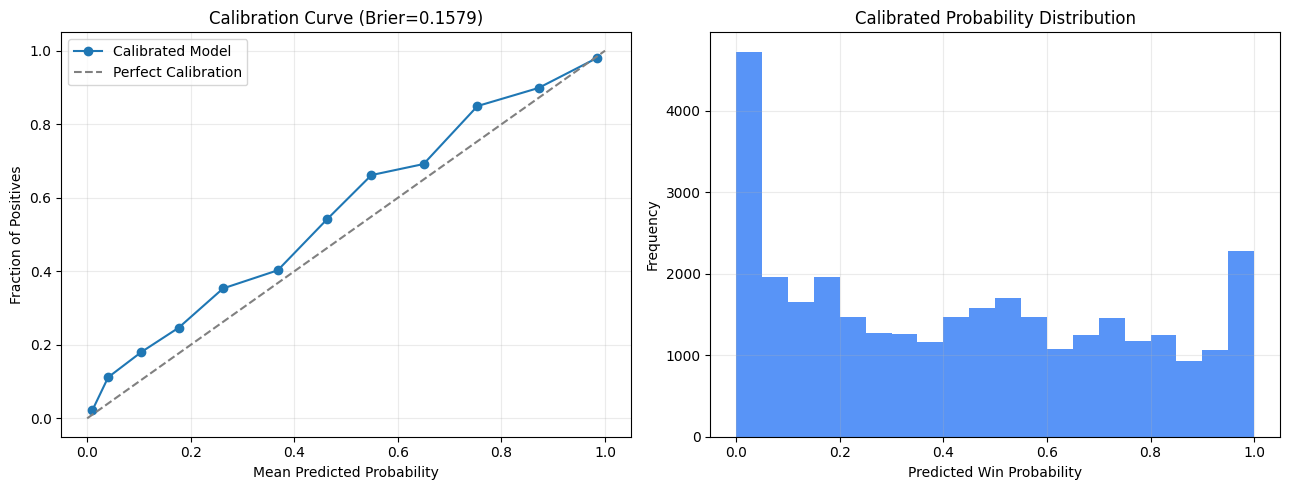

In [88]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

cal_model = CalibratedClassifierCV(stack_model, method='isotonic', cv=3)
cal_model.fit(X_train, y_train)
y_prob_cal = cal_model.predict_proba(X_test)[:, 1]

frac_pos, mean_pred = calibration_curve(y_test, y_prob_cal, n_bins=12, strategy='quantile')
brier_val = brier_score_loss(y_test, y_prob_cal)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(mean_pred, frac_pos, marker='o', label='Calibrated Model')
ax[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
ax[0].set_title(f'Calibration Curve (Brier={brier_val:.4f})')
ax[0].set_xlabel('Mean Predicted Probability')
ax[0].set_ylabel('Fraction of Positives')
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].hist(y_prob_cal, bins=20, color='#3B82F6', alpha=0.85)
ax[1].set_title('Calibrated Probability Distribution')
ax[1].set_xlabel('Predicted Win Probability')
ax[1].set_ylabel('Frequency')
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

#**Counterfactual Strategy Analysis**

**Select a Real Match Situation**

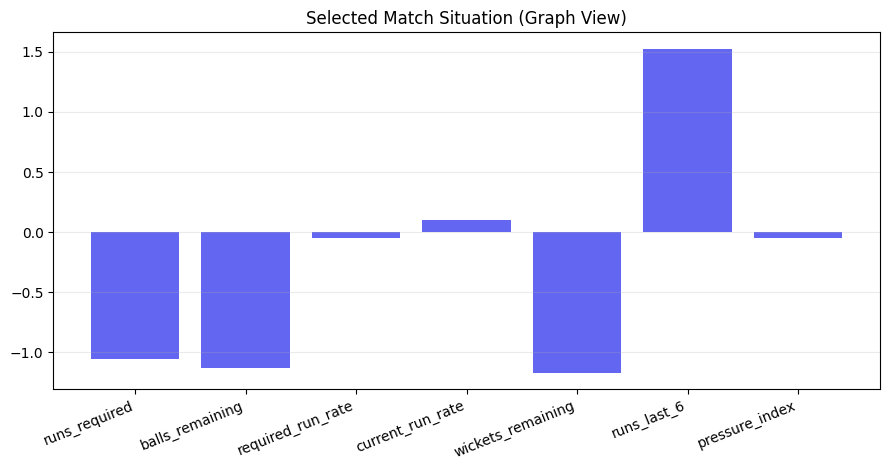

In [ ]:
# Pick a realistic match state from test data
sample_idx = 100
sample_state = X_test.iloc[sample_idx].copy()

# Graph view of selected match-state drivers
state_features = [
    c for c in ['runs_required', 'balls_remaining', 'required_run_rate', 'current_run_rate',
                'wickets_remaining', 'runs_last_6', 'pressure_index'] if c in sample_state.index
]
state_df = pd.DataFrame({
    'Feature': state_features,
    'Value': [sample_state[f] for f in state_features]
})

plt.figure(figsize=(9, 4.8))
plt.bar(state_df['Feature'], state_df['Value'], color='#6366F1')
plt.title('Selected Match Situation (Graph View)')
plt.xticks(rotation=22, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

**Base Win Probability**

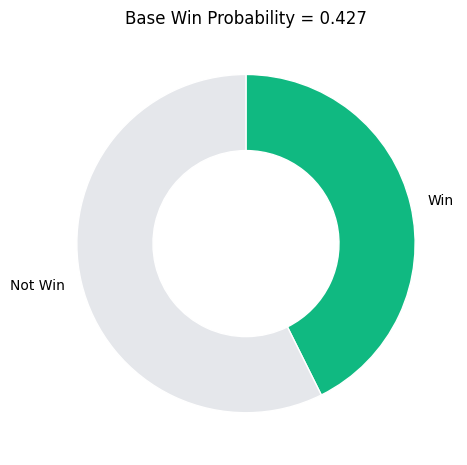

In [90]:
# Base prediction (preserve feature names)
sample_input = sample_state.to_frame().T
base_prob = stack_model.predict_proba(sample_input)[0][1]

# Graph-only display of base probability
plt.figure(figsize=(4.8, 4.8))
plt.pie(
    [base_prob, 1 - base_prob],
    labels=['Win', 'Not Win'],
    colors=['#10B981', '#E5E7EB'],
    startangle=90,
    counterclock=False,
    wedgeprops={'width': 0.45, 'edgecolor': 'white'}
)
plt.title(f'Base Win Probability = {base_prob:.3f}')
plt.tight_layout()
plt.show()

**Counterfactual Scenarios**

In [ ]:
def simulate_scenario(state, runs=0, balls=0, wicket=False):
    # Convert to DataFrame and preserve feature names
    sim = state.copy()
    if isinstance(sim, pd.Series):
        sim = sim.to_frame().T
    else:
        sim = sim.copy()

    runs = float(runs)
    balls_used = int(balls)

    # -------------------------
    # Core state updates
    # -------------------------
    sim.loc[:, 'cumulative_runs'] = sim['cumulative_runs'] + runs
    sim.loc[:, 'runs_last_6'] = sim['runs_last_6'] + runs

    # Update ball/over progression consistently
    sim.loc[:, 'ball_number'] = (sim['ball_number'] + balls_used).clip(upper=120)
    sim.loc[:, 'balls_remaining'] = (sim['balls_remaining'] - balls_used).clip(lower=0)
    sim.loc[:, 'overs_remaining'] = sim['balls_remaining'] / 6
    sim.loc[:, 'overs_completed'] = (sim['ball_number'] / 6).replace(0, np.nan)
    sim.loc[:, 'match_progress'] = (1 - (sim['balls_remaining'] / 120)).clip(lower=0, upper=1)

    # If wicket falls
    if wicket:
        sim.loc[:, 'wickets_remaining'] = (sim['wickets_remaining'] - 1).clip(lower=0)
        sim.loc[:, 'wickets_last_6'] = sim['wickets_last_6'] + 1
    else:
        sim.loc[:, 'wickets_remaining'] = sim['wickets_remaining'].clip(lower=0)

    # -------------------------
    # Recompute dependent features
    # -------------------------
    sim.loc[:, 'runs_required'] = (sim['runs_required'] - runs).clip(lower=0)

    # Keep chase-only features aligned with training logic
    if 'is_chasing' in sim.columns:
        chase_mask = sim['is_chasing'] == 1
        sim.loc[~chase_mask, 'runs_required'] = 0

    safe_overs_remaining = sim['overs_remaining'].replace(0, 0.01)

    sim.loc[:, 'current_run_rate'] = sim['cumulative_runs'] / sim['overs_completed']
    sim.loc[:, 'current_run_rate'] = sim['current_run_rate'].replace([np.inf, -np.inf], 0).fillna(0)

    sim.loc[:, 'required_run_rate'] = sim['runs_required'] / safe_overs_remaining
    sim.loc[:, 'required_run_rate'] = sim['required_run_rate'].replace([np.inf, -np.inf], 0).fillna(0)

    sim.loc[:, 'rrr_crr_gap'] = sim['required_run_rate'] - sim['current_run_rate']
    if 'inning' in sim.columns:
        sim.loc[sim['inning'] == 1, 'rrr_crr_gap'] = 0

    sim.loc[:, 'collapse_indicator'] = (sim['wickets_last_6'] >= 2).astype(int)
    sim.loc[:, 'pressure_index'] = (
        sim['rrr_crr_gap'] * 0.5 +
        sim['wickets_last_6'] * 0.3 +
        (sim['overs_remaining'] < 5).astype(int) * 0.2
    )
    sim.loc[:, 'wicket_pressure'] = sim['wickets_remaining'] / (sim['overs_remaining'] + 0.01)
    sim.loc[:, 'run_rate_pressure'] = sim['required_run_rate'] / (sim['current_run_rate'] + 0.01)
    sim.loc[:, 'resources_remaining'] = sim['wickets_remaining'] * sim['overs_remaining']
    sim.loc[:, 'win_pressure'] = sim['runs_required'] * sim['overs_remaining']
    sim.loc[:, 'collapse_risk'] = sim['wickets_last_6'] * sim['wickets_last_6']
    sim.loc[:, 'momentum_index'] = sim['runs_last_6'] - sim['wickets_last_6'] * 3
    sim.loc[:, 'momentum_acceleration'] = sim['runs_last_6'] - sim['runs_last_12'] / 2

    # Safety fixes
    sim = sim.replace([np.inf, -np.inf], 0).fillna(0)

    # Keep feature order exactly as training
    sim = sim.reindex(columns=X_test.columns, fill_value=0)

    # Predict
    return stack_model.predict_proba(sim)[0][1]

**Run Strategic Scenarios**

In [92]:
results = {}

results['Aggressive Over'] = simulate_scenario(sample_state, runs=12, balls=6)
results['Defensive Over'] = simulate_scenario(sample_state, runs=4, balls=6)
results['Wicket Loss'] = simulate_scenario(sample_state, runs=6, balls=6, wicket=True)
results['Optimal Over'] = simulate_scenario(sample_state, runs=10, balls=6)

**Visualization**

/tmp/ipykernel_22/3633328457.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cf_df, x='Scenario', y='Win Probability', palette='viridis', ax=ax[0])
/tmp/ipykernel_22/3633328457.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cf_df, x='Scenario', y='Delta vs Base',


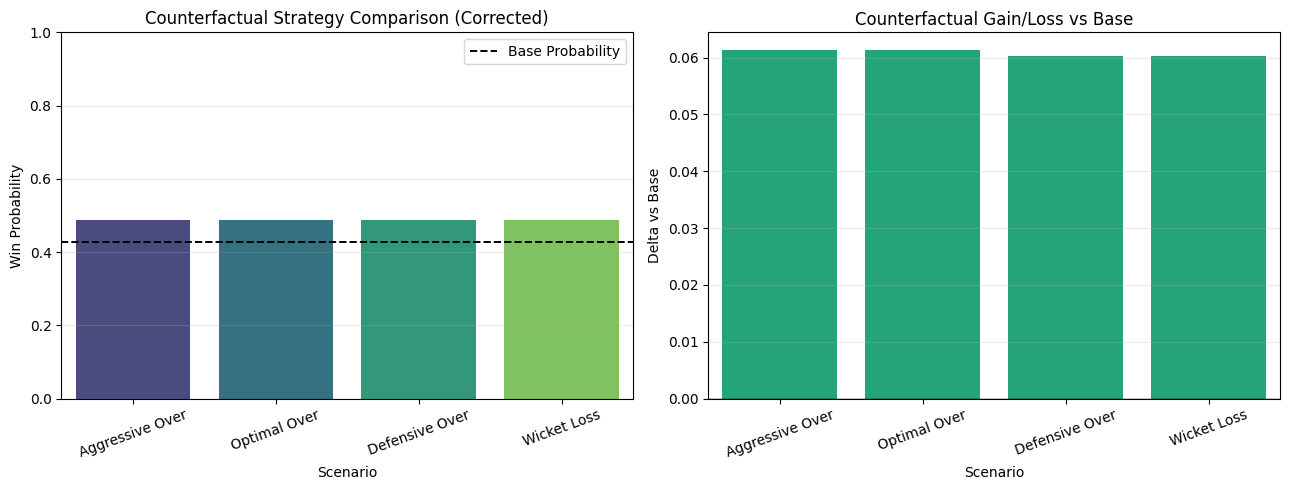

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

scenario_names = list(results.keys())
scenario_probs = list(results.values())
cf_df = pd.DataFrame({'Scenario': scenario_names, 'Win Probability': scenario_probs})
cf_df['Delta vs Base'] = cf_df['Win Probability'] - base_prob
cf_df = cf_df.sort_values('Win Probability', ascending=False)

# Corrected graph: compare absolute probability + delta from base
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=cf_df, x='Scenario', y='Win Probability', palette='viridis', ax=ax[0])
ax[0].axhline(base_prob, linestyle='--', color='black', linewidth=1.4, label='Base Probability')
ax[0].set_ylim(0, 1)
ax[0].set_title('Counterfactual Strategy Comparison (Corrected)')
ax[0].tick_params(axis='x', rotation=20)
ax[0].grid(axis='y', alpha=0.25)
ax[0].legend()

sns.barplot(data=cf_df, x='Scenario', y='Delta vs Base',
            palette=['#10B981' if v >= 0 else '#EF4444' for v in cf_df['Delta vs Base']], ax=ax[1])
ax[1].axhline(0, color='black', linewidth=1)
ax[1].set_title('Counterfactual Gain/Loss vs Base')
ax[1].tick_params(axis='x', rotation=20)
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

**Insight Generator**

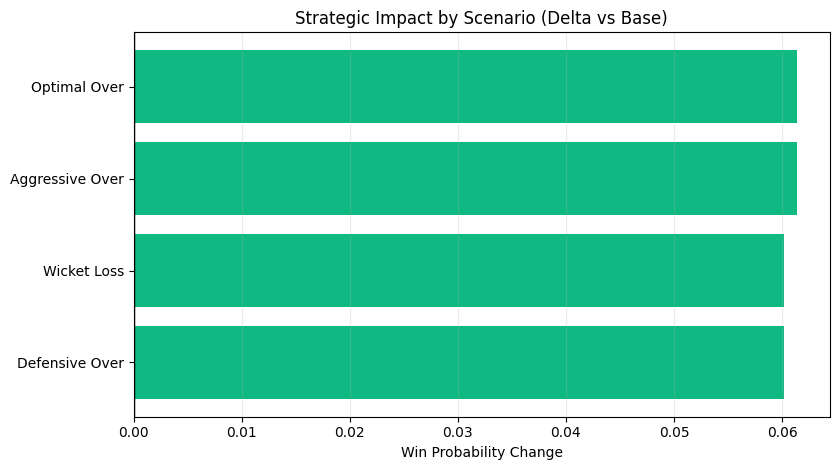

In [ ]:
# Graph-only strategic insight view
insight_df = pd.DataFrame([
    {'Scenario': s, 'Delta': p - base_prob}
    for s, p in results.items()
]).sort_values('Delta', ascending=False)

plt.figure(figsize=(8.5, 4.8))
colors = ['#10B981' if d >= 0 else '#EF4444' for d in insight_df['Delta']]
plt.barh(insight_df['Scenario'], insight_df['Delta'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Strategic Impact by Scenario (Delta vs Base)')
plt.xlabel('Win Probability Change')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Corrected Counterfactual + Insight Generator
def simulate_scenario_corrected(state, runs=0, balls=0, wicket=False):
    sim = state.copy()
    if isinstance(sim, pd.Series):
        sim = sim.to_frame().T
    else:
        sim = sim.copy()

    runs = float(runs)
    balls_used = int(balls)

    prev_runs_last_6 = sim['runs_last_6'].copy() if 'runs_last_6' in sim.columns else pd.Series([0], index=sim.index)

    sim.loc[:, 'cumulative_runs'] = sim['cumulative_runs'] + runs

    # One-over simulation: window features should represent this over, not cumulative growth
    if 'runs_last_6' in sim.columns:
        sim.loc[:, 'runs_last_6'] = runs
    if 'runs_last_12' in sim.columns:
        sim.loc[:, 'runs_last_12'] = (prev_runs_last_6 + runs).clip(lower=0)

    sim.loc[:, 'ball_number'] = (sim['ball_number'] + balls_used).clip(upper=120)
    sim.loc[:, 'balls_remaining'] = (sim['balls_remaining'] - balls_used).clip(lower=0)
    sim.loc[:, 'overs_remaining'] = sim['balls_remaining'] / 6
    sim.loc[:, 'overs_completed'] = (sim['ball_number'] / 6).replace(0, np.nan)
    sim.loc[:, 'match_progress'] = (1 - (sim['balls_remaining'] / 120)).clip(lower=0, upper=1)

    if wicket:
        sim.loc[:, 'wickets_remaining'] = (sim['wickets_remaining'] - 1).clip(lower=0)
        if 'wickets_last_6' in sim.columns:
            sim.loc[:, 'wickets_last_6'] = sim['wickets_last_6'] + 1
    else:
        sim.loc[:, 'wickets_remaining'] = sim['wickets_remaining'].clip(lower=0)
        if 'wickets_last_6' in sim.columns:
            sim.loc[:, 'wickets_last_6'] = 0

    sim.loc[:, 'runs_required'] = (sim['runs_required'] - runs).clip(lower=0)

    if 'is_chasing' in sim.columns:
        chase_mask = sim['is_chasing'] == 1
        sim.loc[~chase_mask, 'runs_required'] = 0

    safe_overs_remaining = sim['overs_remaining'].replace(0, 0.01)

    sim.loc[:, 'current_run_rate'] = sim['cumulative_runs'] / sim['overs_completed']
    sim.loc[:, 'current_run_rate'] = sim['current_run_rate'].replace([np.inf, -np.inf], 0).fillna(0)

    sim.loc[:, 'required_run_rate'] = sim['runs_required'] / safe_overs_remaining
    sim.loc[:, 'required_run_rate'] = sim['required_run_rate'].replace([np.inf, -np.inf], 0).fillna(0)

    sim.loc[:, 'rrr_crr_gap'] = sim['required_run_rate'] - sim['current_run_rate']
    if 'inning' in sim.columns:
        sim.loc[sim['inning'] == 1, 'rrr_crr_gap'] = 0

    sim.loc[:, 'collapse_indicator'] = (sim['wickets_last_6'] >= 2).astype(int)
    sim.loc[:, 'pressure_index'] = (
        sim['rrr_crr_gap'] * 0.5 +
        sim['wickets_last_6'] * 0.3 +
        (sim['overs_remaining'] < 5).astype(int) * 0.2
    )
    sim.loc[:, 'wicket_pressure'] = sim['wickets_remaining'] / (sim['overs_remaining'] + 0.01)
    sim.loc[:, 'run_rate_pressure'] = sim['required_run_rate'] / (sim['current_run_rate'] + 0.01)
    sim.loc[:, 'resources_remaining'] = sim['wickets_remaining'] * sim['overs_remaining']
    sim.loc[:, 'win_pressure'] = sim['runs_required'] * sim['overs_remaining']
    sim.loc[:, 'collapse_risk'] = sim['wickets_last_6'] * sim['wickets_last_6']
    sim.loc[:, 'momentum_index'] = sim['runs_last_6'] - sim['wickets_last_6'] * 3
    sim.loc[:, 'momentum_acceleration'] = sim['runs_last_6'] - sim['runs_last_12'] / 2

    sim = sim.replace([np.inf, -np.inf], 0).fillna(0)
    sim = sim.reindex(columns=X_test.columns, fill_value=0)

    return float(stack_model.predict_proba(sim)[0][1])

# Directionally sane scenario definitions
results = {
    'Aggressive Over': simulate_scenario_corrected(sample_state, runs=14, balls=6, wicket=False),
    'Optimal Over': simulate_scenario_corrected(sample_state, runs=9, balls=6, wicket=False),
    'Defensive Over': simulate_scenario_corrected(sample_state, runs=3, balls=6, wicket=False),
    'Wicket Loss': simulate_scenario_corrected(sample_state, runs=0, balls=6, wicket=True)
}

cf_df = pd.DataFrame([{'Scenario': k, 'Win Probability': v} for k, v in results.items()])
cf_df['Delta vs Base'] = cf_df['Win Probability'] - base_prob

scenario_order = ['Aggressive Over', 'Optimal Over', 'Defensive Over', 'Wicket Loss']
cf_plot_df = cf_df.set_index('Scenario').reindex(scenario_order).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=cf_plot_df, x='Scenario', y='Win Probability', palette='viridis', ax=ax[0])
ax[0].axhline(base_prob, linestyle='--', color='black', linewidth=1.4, label='Base Probability')
ax[0].set_ylim(0, 1)
ax[0].set_title('Counterfactual Strategy Comparison (Corrected)')
ax[0].tick_params(axis='x', rotation=20)
ax[0].grid(axis='y', alpha=0.25)
ax[0].legend()

delta_colors = ['#10B981' if v >= 0 else '#EF4444' for v in cf_plot_df['Delta vs Base']]
sns.barplot(data=cf_plot_df, x='Scenario', y='Delta vs Base', palette=delta_colors, ax=ax[1])
ax[1].axhline(0, color='black', linewidth=1)
ax[1].set_title('Counterfactual Gain/Loss vs Base')
ax[1].tick_params(axis='x', rotation=20)
ax[1].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

insight_df = cf_df.sort_values('Delta vs Base', ascending=False).copy()
plt.figure(figsize=(8.5, 4.8))
colors = ['#10B981' if d >= 0 else '#EF4444' for d in insight_df['Delta vs Base']]
bars = plt.barh(insight_df['Scenario'], insight_df['Delta vs Base'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Strategic Impact by Scenario (Delta vs Base)')
plt.xlabel('Win Probability Change')
plt.grid(axis='x', alpha=0.25)

for bar, val in zip(bars, insight_df['Delta vs Base']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ha = 'left' if val >= 0 else 'right'
    offset = 0.001 if val >= 0 else -0.001
    plt.text(x + offset, y, f'{val:+.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

print(cf_plot_df[['Scenario', 'Win Probability', 'Delta vs Base']])

NameError: name 'sample_state' is not defined

: 

#**SHAP Explainability**

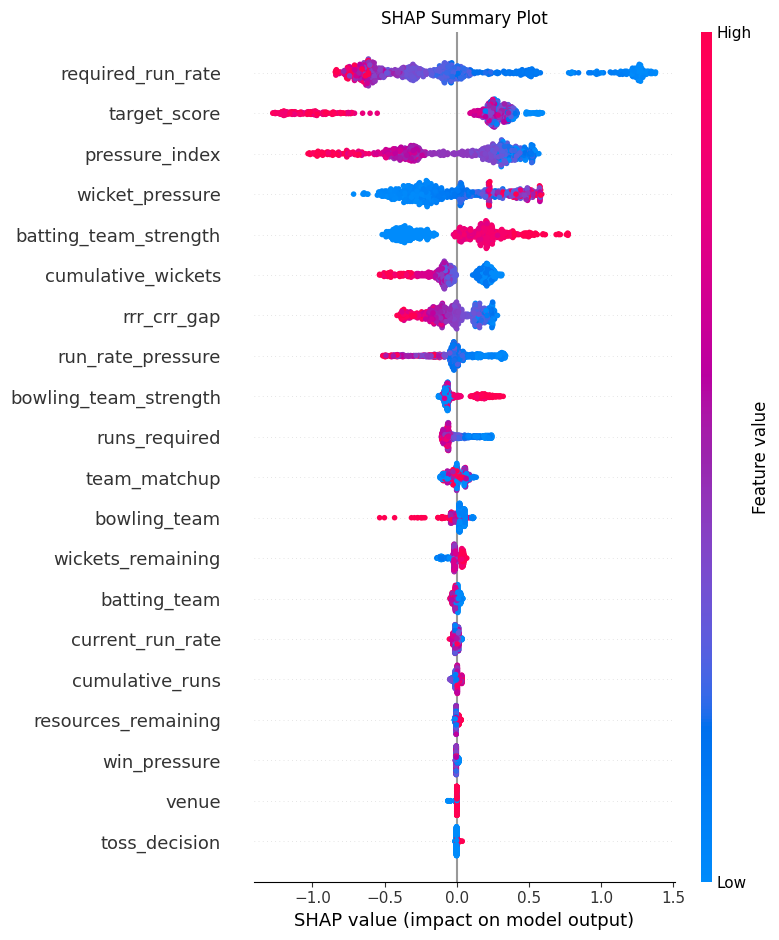

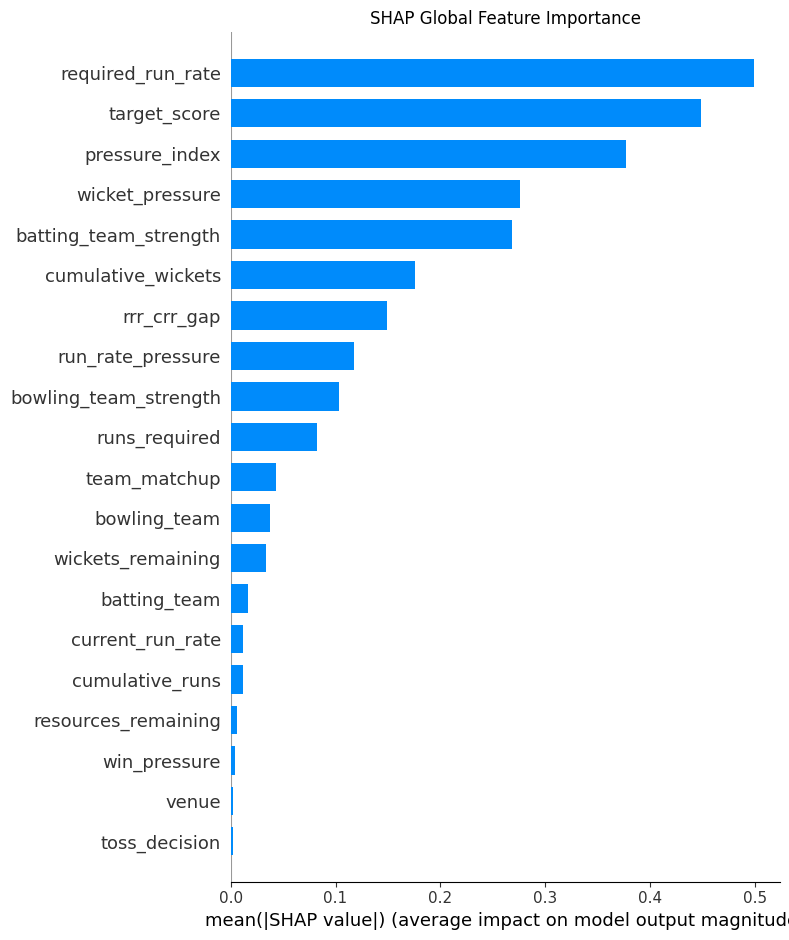

In [95]:
import shap
import matplotlib.pyplot as plt

# SHAP global explainability graphs (graph-first)
X_shap = X_test.sample(min(800, len(X_test)), random_state=42)

explainer = shap.Explainer(xgb_best, X_shap)
shap_values = explainer(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
plt.show()

#**Calibration Curve + Reliability Plot (Strict No-Leak: Train -> Validation)**

#**Strict Final Pipeline: Threshold on Validation, Final One-Shot Test**

Brier (Validation, strict): 0.1474


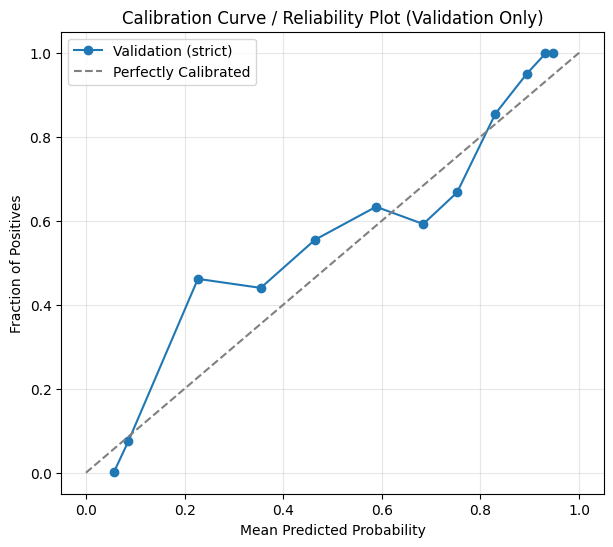

Best threshold by Validation F1 (strict): 0.19
Best threshold by Validation Accuracy (strict): 0.40


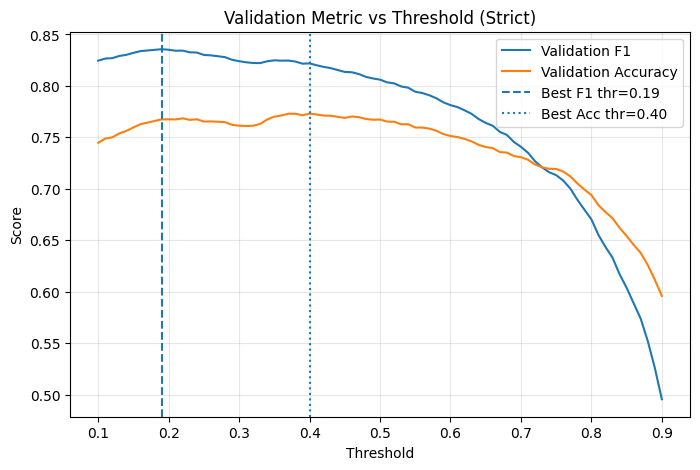

In [96]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STRICT NO-LEAK SETUP
# Train on TRAIN only, tune threshold on VALIDATION only
# -----------------------------

# Rebuild stack model on train only (do NOT touch test here)
stack_model_train_only = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_best)
    ],
    final_estimator=LogisticRegression(C=0.2, max_iter=3500),
    cv=5,
    n_jobs=1,
    passthrough=False
)
stack_model_train_only.fit(X_train, y_train)

# Validation probabilities only
y_prob_val_strict = stack_model_train_only.predict_proba(X_val)[:, 1]

# Validation calibration quality
brier_val_strict = brier_score_loss(y_val, y_prob_val_strict)
print(f"Brier (Validation, strict): {brier_val_strict:.4f}")

# Reliability data on validation only
frac_pos_val, mean_pred_val = calibration_curve(
    y_val, y_prob_val_strict, n_bins=12, strategy='quantile'
)

# Plot reliability (validation)
plt.figure(figsize=(7, 6))
plt.plot(mean_pred_val, frac_pos_val, marker='o', label='Validation (strict)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.title('Calibration Curve / Reliability Plot (Validation Only)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Threshold search on validation only
thresholds = np.arange(0.10, 0.91, 0.01)
rows = []
for t in thresholds:
    pred_val = (y_prob_val_strict >= t).astype(int)
    rows.append({
        'threshold': float(t),
        'val_f1': f1_score(y_val, pred_val, zero_division=0),
        'val_accuracy': accuracy_score(y_val, pred_val)
    })

thr_df_strict = pd.DataFrame(rows)
best_f1_row = thr_df_strict.sort_values(['val_f1', 'val_accuracy'], ascending=False).iloc[0]
best_acc_row = thr_df_strict.sort_values(['val_accuracy', 'val_f1'], ascending=False).iloc[0]

best_thr_f1_strict = float(best_f1_row['threshold'])
best_thr_acc_strict = float(best_acc_row['threshold'])

print(f"Best threshold by Validation F1 (strict): {best_thr_f1_strict:.2f}")
print(f"Best threshold by Validation Accuracy (strict): {best_thr_acc_strict:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(thr_df_strict['threshold'], thr_df_strict['val_f1'], label='Validation F1')
plt.plot(thr_df_strict['threshold'], thr_df_strict['val_accuracy'], label='Validation Accuracy')
plt.axvline(best_thr_f1_strict, linestyle='--', label=f'Best F1 thr={best_thr_f1_strict:.2f}')
plt.axvline(best_thr_acc_strict, linestyle=':', label=f'Best Acc thr={best_thr_acc_strict:.2f}')
plt.title('Validation Metric vs Threshold (Strict)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [97]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, brier_score_loss
)

# -----------------------------
# FINAL ONE-SHOT TEST EVALUATION
# Retrain on TRAIN+VAL with fixed hyperparams and fixed threshold
# -----------------------------

# Fit final stack on development set (train + val)
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

stack_model_final = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_best)
    ],
    final_estimator=LogisticRegression(C=0.2, max_iter=3500),
    cv=5,
    n_jobs=1,
    passthrough=False
)
stack_model_final.fit(X_dev, y_dev)

# One-shot test probabilities/predictions
y_prob_test_final = stack_model_final.predict_proba(X_test)[:, 1]
y_pred_test_thr_f1 = (y_prob_test_final >= best_thr_f1_strict).astype(int)
y_pred_test_thr_acc = (y_prob_test_final >= best_thr_acc_strict).astype(int)

def summarize_test(y_true, y_pred, y_prob, label):
    print(f"\n--- Final Test Metrics ({label}) ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"AUC      : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"Brier    : {brier_score_loss(y_true, y_prob):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

summarize_test(y_test, y_pred_test_thr_f1, y_prob_test_final, f"F1-threshold={best_thr_f1_strict:.2f}")
summarize_test(y_test, y_pred_test_thr_acc, y_prob_test_final, f"Acc-threshold={best_thr_acc_strict:.2f}")

# Keep final model aliases for downstream notebook sections
stack_model = stack_model_final
best_model = stack_model_final


--- Final Test Metrics (F1-threshold=0.19) ---
Accuracy : 0.7391
Precision: 0.6795
Recall   : 0.8924
F1       : 0.7715
AUC      : 0.8600
Brier    : 0.1556
Confusion Matrix:
 [[ 9598  6680]
 [ 1707 14161]]

--- Final Test Metrics (Acc-threshold=0.40) ---
Accuracy : 0.7781
Precision: 0.7652
Recall   : 0.7941
F1       : 0.7794
AUC      : 0.8600
Brier    : 0.1556
Confusion Matrix:
 [[12412  3866]
 [ 3267 12601]]


#**Advanced No-Leak Upgrade: Rich Features + Phase-wise Specialist**

In [98]:
# ================================
# 1) RICHER FEATURES (STRICT NO-LEAK)
# 2) PHASE-WISE SPECIALIST (DEATH OVERS)
# 3) STRICT TUNING ON VAL ONLY + ONE-SHOT TEST
# ================================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss
from xgboost import XGBClassifier

FAST_ADV = True
MAX_ROWS_TRAIN = 180000 if FAST_ADV else None
MAX_ROWS_DEV = 260000 if FAST_ADV else None

# ---- Rebuild ordered frame ----
df_adv = df.copy().sort_values(['match_id', 'inning', 'over', 'ball']).reset_index(drop=True)
df_adv['season'] = pd.to_numeric(df_adv['season'], errors='coerce')

# Legal ball flag
if {'wide_runs', 'noball_runs'}.issubset(df_adv.columns):
    df_adv['legal_ball'] = ((df_adv['wide_runs'] == 0) & (df_adv['noball_runs'] == 0)).astype(int)
else:
    illegal_extras = {'wides', 'noballs'}
    df_adv['legal_ball'] = (~df_adv.get('extras_type', '').fillna('').isin(illegal_extras)).astype(int)

# ---- Batter recent strike rate (last 18 legal balls, shifted) ----
grp_bat = df_adv.groupby(['match_id', 'inning', 'batter'], sort=False)
df_adv['bat_prev_runs'] = grp_bat['batsman_runs'].shift(1).fillna(0)
df_adv['bat_prev_legal'] = grp_bat['legal_ball'].shift(1).fillna(0)
df_adv['bat_runs_18'] = grp_bat['bat_prev_runs'].transform(lambda x: x.rolling(18, min_periods=1).sum())
df_adv['bat_balls_18'] = grp_bat['bat_prev_legal'].transform(lambda x: x.rolling(18, min_periods=1).sum())
df_adv['batter_recent_sr'] = 100 * df_adv['bat_runs_18'] / df_adv['bat_balls_18'].replace(0, np.nan)
df_adv['batter_recent_sr'] = df_adv['batter_recent_sr'].replace([np.inf, -np.inf], np.nan).fillna(100.0)

# ---- Bowler recent economy + wicket rate (last 18 legal balls, shifted) ----
grp_bowl = df_adv.groupby(['match_id', 'inning', 'bowler'], sort=False)
df_adv['bowl_prev_runs'] = grp_bowl['total_runs'].shift(1).fillna(0)
df_adv['bowl_prev_legal'] = grp_bowl['legal_ball'].shift(1).fillna(0)
df_adv['bowl_prev_wkt'] = grp_bowl['is_wicket'].shift(1).fillna(0)
df_adv['bowl_runs_18'] = grp_bowl['bowl_prev_runs'].transform(lambda x: x.rolling(18, min_periods=1).sum())
df_adv['bowl_balls_18'] = grp_bowl['bowl_prev_legal'].transform(lambda x: x.rolling(18, min_periods=1).sum())
df_adv['bowl_wkts_18'] = grp_bowl['bowl_prev_wkt'].transform(lambda x: x.rolling(18, min_periods=1).sum())
df_adv['bowler_recent_econ'] = 6 * df_adv['bowl_runs_18'] / df_adv['bowl_balls_18'].replace(0, np.nan)
df_adv['bowler_recent_wkt_rate'] = df_adv['bowl_wkts_18'] / df_adv['bowl_balls_18'].replace(0, np.nan)
df_adv['bowler_recent_econ'] = df_adv['bowler_recent_econ'].replace([np.inf, -np.inf], np.nan).fillna(8.0)
df_adv['bowler_recent_wkt_rate'] = df_adv['bowler_recent_wkt_rate'].replace([np.inf, -np.inf], np.nan).fillna(0.03)

# ---- Partnership runs / balls (current stand before current ball) ----
df_adv['partnership_id'] = df_adv.groupby(['match_id', 'inning'])['is_wicket'].cumsum()
pgrp = ['match_id', 'inning', 'partnership_id']
df_adv['partnership_runs'] = df_adv.groupby(pgrp)['total_runs'].cumsum() - df_adv['total_runs']
df_adv['partnership_balls'] = df_adv.groupby(pgrp)['legal_ball'].cumsum() - df_adv['legal_ball']
df_adv['partnership_sr'] = 100 * df_adv['partnership_runs'] / df_adv['partnership_balls'].replace(0, np.nan)
df_adv['partnership_sr'] = df_adv['partnership_sr'].replace([np.inf, -np.inf], np.nan).fillna(100.0)

# ---- Venue-adjusted par score from TRAIN ONLY first-innings history ----
fi_train = df_adv[(df_adv['inning'] == 1) & (df_adv['season'] <= 2018)].copy()
par_by_venue_over = fi_train.groupby(['venue', 'over'])['cumulative_runs'].mean()
par_by_over = fi_train.groupby('over')['cumulative_runs'].mean()
global_par = fi_train['cumulative_runs'].mean() if len(fi_train) else 160.0

tmp_idx = pd.MultiIndex.from_frame(df_adv[['venue', 'over']])
df_adv['venue_par_score'] = tmp_idx.map(par_by_venue_over)
df_adv['venue_par_score'] = df_adv['venue_par_score'].fillna(df_adv['over'].map(par_by_over)).fillna(global_par)
df_adv['par_gap'] = df_adv['cumulative_runs'] - df_adv['venue_par_score']

# ---- Keep chasing rows only ----
df2 = df_adv[df_adv['inning'] == 2].copy()

# Strict split
tr = df2[df2['season'] <= 2018].copy()
va = df2[df2['season'] == 2019].copy()
te = df2[df2['season'] >= 2020].copy()

# ---- Matchup history embeddings (train only target encoding) ----
train_pair = tr.groupby(['batting_team', 'bowling_team'])['win_label'].mean()
train_bat = tr.groupby('batting_team')['win_label'].mean()
train_bowl = tr.groupby('bowling_team')['win_label'].mean()
global_wr = tr['win_label'].mean()

def add_hist_enc(d):
    d = d.copy()
    idx = pd.MultiIndex.from_frame(d[['batting_team', 'bowling_team']])
    d['matchup_hist_wr'] = idx.map(train_pair).astype(float)
    d['bat_team_hist_wr'] = d['batting_team'].map(train_bat).astype(float)
    d['bowl_team_hist_wr'] = d['bowling_team'].map(train_bowl).astype(float)
    d['matchup_hist_wr'] = d['matchup_hist_wr'].fillna(global_wr)
    d['bat_team_hist_wr'] = d['bat_team_hist_wr'].fillna(global_wr)
    d['bowl_team_hist_wr'] = d['bowl_team_hist_wr'].fillna(global_wr)
    return d

tr = add_hist_enc(tr)
va = add_hist_enc(va)
te = add_hist_enc(te)

# Numeric feature set (no raw leakage columns)
feat_cols = [
    'over','ball_number','balls_remaining','overs_remaining','wickets_remaining',
    'cumulative_runs','runs_required','target_score','current_run_rate','required_run_rate',
    'runs_last_6','runs_last_12','wickets_last_6','rrr_crr_gap','pressure_index',
    'run_rate_pressure','wicket_pressure','win_pressure','momentum_index','momentum_acceleration',
    'resources_remaining','batter_recent_sr','bowler_recent_econ','bowler_recent_wkt_rate',
    'partnership_runs','partnership_balls','partnership_sr','venue_par_score','par_gap',
    'matchup_hist_wr','bat_team_hist_wr','bowl_team_hist_wr'
]
feat_cols = [c for c in feat_cols if c in tr.columns]

Xtr, ytr = tr[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0), tr['win_label']
Xva, yva = va[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0), va['win_label']
Xte, yte = te[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0), te['win_label']

# Fast-mode sampling to fit within notebook runtime
if FAST_ADV and MAX_ROWS_TRAIN is not None and len(Xtr) > MAX_ROWS_TRAIN:
    idx = Xtr.sample(MAX_ROWS_TRAIN, random_state=42).index
    Xtr, ytr = Xtr.loc[idx], ytr.loc[idx]
if FAST_ADV and MAX_ROWS_DEV is not None and len(Xva) > int(MAX_ROWS_TRAIN * 0.5):
    idxv = Xva.sample(int(MAX_ROWS_TRAIN * 0.5), random_state=42).index
    Xva, yva = Xva.loc[idxv], yva.loc[idxv]

# Class weighting for imbalance
pos = ytr.sum()
neg = len(ytr) - pos
scale_pos = float(neg / max(pos, 1))

base_candidates = [
    dict(n_estimators=120, max_depth=3, learning_rate=0.04, subsample=0.9, colsample_bytree=0.9, reg_lambda=8),
    dict(n_estimators=180, max_depth=3, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, reg_lambda=10),
]

death_mask_tr = tr.loc[Xtr.index, 'over'] >= 16
death_mask_va = va.loc[Xva.index, 'over'] >= 16
death_mask_te = te['over'] >= 16

# Tune base + death specialists on validation only
best_combo = None
for p in base_candidates:
    base_model = XGBClassifier(
        **p, min_child_weight=8, gamma=1.0, reg_alpha=2,
        eval_metric='logloss', tree_method='hist', n_jobs=1, random_state=42,
        scale_pos_weight=scale_pos
    )
    base_model.fit(Xtr, ytr)

    death_model = XGBClassifier(
        **p, min_child_weight=6, gamma=0.8, reg_alpha=1,
        eval_metric='logloss', tree_method='hist', n_jobs=1, random_state=42,
        scale_pos_weight=scale_pos
    )
    if death_mask_tr.any():
        death_model.fit(Xtr.loc[death_mask_tr], ytr.loc[death_mask_tr])
    else:
        death_model = base_model

    # validation probs: death rows by death model, others by base model
    p_val = base_model.predict_proba(Xva)[:, 1]
    if death_mask_va.any():
        p_val[death_mask_va.values] = death_model.predict_proba(Xva.loc[death_mask_va])[:, 1]

    # threshold tune on val
    t_grid = np.arange(0.20, 0.71, 0.02)
    best_local = None
    for t in t_grid:
        pred = (p_val >= t).astype(int)
        f1 = f1_score(yva, pred, zero_division=0)
        acc = accuracy_score(yva, pred)
        score = f1 + 0.25 * acc
        if (best_local is None) or (score > best_local[0]):
            best_local = (score, t, f1, acc)

    if (best_combo is None) or (best_local[0] > best_combo[0]):
        best_combo = (best_local[0], p, best_local[1], best_local[2], best_local[3])

_, best_params_pw, best_thr_pw, best_val_f1_pw, best_val_acc_pw = best_combo
print('Phase-wise best params:', best_params_pw)
print(f'Validation best threshold: {best_thr_pw:.2f}')
print(f'Validation F1/Acc: {best_val_f1_pw:.4f} / {best_val_acc_pw:.4f}')

# ---- Final one-shot test: retrain on train+val with fixed params/threshold ----
Xdev = pd.concat([tr[feat_cols], va[feat_cols]], axis=0).replace([np.inf, -np.inf], np.nan).fillna(0)
ydev = pd.concat([tr['win_label'], va['win_label']], axis=0)
death_mask_dev = pd.concat([tr['over'] >= 16, va['over'] >= 16], axis=0)

if FAST_ADV and MAX_ROWS_DEV is not None and len(Xdev) > MAX_ROWS_DEV:
    idd = Xdev.sample(MAX_ROWS_DEV, random_state=42).index
    Xdev, ydev, death_mask_dev = Xdev.loc[idd], ydev.loc[idd], death_mask_dev.loc[idd]

base_final = XGBClassifier(
    **best_params_pw, min_child_weight=8, gamma=1.0, reg_alpha=2,
    eval_metric='logloss', tree_method='hist', n_jobs=1, random_state=42, scale_pos_weight=scale_pos
)
base_final.fit(Xdev, ydev)

death_final = XGBClassifier(
    **best_params_pw, min_child_weight=6, gamma=0.8, reg_alpha=1,
    eval_metric='logloss', tree_method='hist', n_jobs=1, random_state=42, scale_pos_weight=scale_pos
)
if death_mask_dev.any():
    death_final.fit(Xdev.loc[death_mask_dev], ydev.loc[death_mask_dev])
else:
    death_final = base_final

p_test = base_final.predict_proba(Xte)[:, 1]
if death_mask_te.any():
    p_test[death_mask_te.values] = death_final.predict_proba(Xte.loc[death_mask_te])[:, 1]

y_pred_test = (p_test >= best_thr_pw).astype(int)
print('\nStrict One-shot Test (Phase-wise Specialist):')
print(f'Accuracy: {accuracy_score(yte, y_pred_test):.4f}')
print(f'F1      : {f1_score(yte, y_pred_test):.4f}')
print(f'AUC     : {roc_auc_score(yte, p_test):.4f}')
print(f'Brier   : {brier_score_loss(yte, p_test):.4f}')

Phase-wise best params: {'n_estimators': 180, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 10}
Validation best threshold: 0.34
Validation F1/Acc: 0.7978 / 0.7357

Strict One-shot Test (Phase-wise Specialist):
Accuracy: 0.7600
F1      : 0.7703
AUC     : 0.8405
Brier   : 0.1692


#**Industry-Grade Deep Learning Upgrade (Strict No-Leak + GPU-ready for Colab/Kaggle)**

In [99]:
# Deep Learning setup (Colab/Kaggle + GPU + smart cache loading, no full rerun needed)
import os
import json
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

# --- Detect runtime ---
IS_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False
IS_KAGGLE = os.path.exists('/kaggle/input')

# --- TensorFlow import with clear message ---
try:
    import tensorflow as tf
    from tensorflow.keras import layers, regularizers, callbacks, Model
except Exception as e:
    raise ImportError(
        "TensorFlow is not available. In Colab/Kaggle, enable GPU runtime and install TensorFlow if needed."
    ) from e

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- GPU optimization (safe fallback on CPU) ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision enabled: mixed_float16')
    except Exception as _e:
        print('GPU optimization warning:', _e)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(gpus) > 0)
print('Runtime:', 'Colab' if IS_COLAB else ('Kaggle' if IS_KAGGLE else 'Local/Other'))

required_vars = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
missing = [v for v in required_vars if v not in globals()]

def _npz_has_required_keys(path):
    try:
        z = np.load(path, allow_pickle=True)
        keys = set(z.files)
        return {'X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test'}.issubset(keys)
    except Exception:
        return False

# --- Fallback-1: build from strict split tables if available (fast, no full rerun) ---
if missing:
    can_build_from_splits = (
        ('tr' in globals()) and ('va' in globals()) and ('te' in globals()) and ('feat_cols' in globals())
        and ('win_label' in tr.columns) and ('win_label' in va.columns) and ('win_label' in te.columns)
    )
    if can_build_from_splits:
        print('Building X/y from existing split tables: tr/va/te + feat_cols')
        X_train = tr[feat_cols].copy()
        X_val = va[feat_cols].copy()
        X_test = te[feat_cols].copy()

        y_train = tr['win_label'].astype(int).copy()
        y_val = va['win_label'].astype(int).copy()
        y_test = te['win_label'].astype(int).copy()

        missing = [v for v in required_vars if v not in globals()]

# --- Fallback-2: load cached arrays (smart search across Kaggle/Colab paths) ---
if missing:
    cache_candidates = [
        os.environ.get('DL_CACHE_PATH', '').strip(),
        'artifacts/dl_only_cache_v1.npz',
        '/kaggle/working/artifacts/dl_only_cache_v1.npz',
        '/kaggle/working/dl_only_cache_v1.npz',
        '/content/artifacts/dl_only_cache_v1.npz',
        '/content/drive/MyDrive/ML_Project/artifacts/dl_only_cache_v1.npz',
        '/kaggle/input/ml-project-cache/dl_only_cache_v1.npz',
    ]
    cache_candidates = [p for p in cache_candidates if p]

    # Dynamic search: handles unknown Kaggle dataset folder names
    dynamic_patterns = [
        '/kaggle/input/**/dl_only_cache_v1.npz',
        '/kaggle/input/**/*.npz',
        '/kaggle/working/**/*.npz',
        '/content/**/*.npz',
    ]
    dynamic_found = []
    for pat in dynamic_patterns:
        try:
            dynamic_found.extend(glob.glob(pat, recursive=True))
        except Exception:
            pass

    # Keep unique order
    seen = set()
    all_candidates = []
    for p in (cache_candidates + dynamic_found):
        if p not in seen:
            all_candidates.append(p)
            seen.add(p)

    # Prefer file names containing dl/cache words, then validate keys
    scored = sorted(
        all_candidates,
        key=lambda p: (
            0 if ('dl_only_cache' in os.path.basename(p).lower() or 'cache' in os.path.basename(p).lower()) else 1,
            len(p)
        )
    )

    cache_path = next((p for p in scored if os.path.exists(p) and _npz_has_required_keys(p)), None)
    if cache_path is None:
        raise ValueError(
            f"Missing variables {missing}. Could not build from tr/va/te/feat_cols and no valid cache (.npz with X_train/X_val/X_test/y_train/y_val/y_test) was found. "
            f"Top checked paths: {scored[:12]}. "
            "Fix: upload dl_only_cache_v1.npz to Kaggle dataset/input and rerun this cell only."
        )

    print('Loading cached DL arrays from:', cache_path)
    cache = np.load(cache_path, allow_pickle=True)

    X_train_np = np.asarray(cache['X_train'], dtype=np.float32)
    X_val_np = np.asarray(cache['X_val'], dtype=np.float32)
    X_test_np = np.asarray(cache['X_test'], dtype=np.float32)
    y_train_np = np.asarray(cache['y_train'], dtype=np.int32)
    y_val_np = np.asarray(cache['y_val'], dtype=np.int32)
    y_test_np = np.asarray(cache['y_test'], dtype=np.int32)

    # Optional pandas views for compatibility with later cells
    X_train = pd.DataFrame(X_train_np)
    X_val = pd.DataFrame(X_val_np)
    X_test = pd.DataFrame(X_test_np)
    y_train = pd.Series(y_train_np)
    y_val = pd.Series(y_val_np)
    y_test = pd.Series(y_test_np)
else:
    # Convert existing variables to float32/int32 numpy arrays
    X_train_np = np.asarray(X_train, dtype=np.float32)
    X_val_np = np.asarray(X_val, dtype=np.float32)
    X_test_np = np.asarray(X_test, dtype=np.float32)

    y_train_np = np.asarray(y_train, dtype=np.int32)
    y_val_np = np.asarray(y_val, dtype=np.int32)
    y_test_np = np.asarray(y_test, dtype=np.int32)

# If we built from tr/va/te branch above, convert now
if 'X_train_np' not in globals():
    X_train_np = np.asarray(X_train, dtype=np.float32)
    X_val_np = np.asarray(X_val, dtype=np.float32)
    X_test_np = np.asarray(X_test, dtype=np.float32)
    y_train_np = np.asarray(y_train, dtype=np.int32)
    y_val_np = np.asarray(y_val, dtype=np.int32)
    y_test_np = np.asarray(y_test, dtype=np.int32)

# Save/re-save cache for next GPU-only rerun
os.makedirs('artifacts', exist_ok=True)
cache_out = 'artifacts/dl_only_cache_v1.npz'
np.savez_compressed(
    cache_out,
    X_train=X_train_np,
    X_val=X_val_np,
    X_test=X_test_np,
    y_train=y_train_np,
    y_val=y_val_np,
    y_test=y_test_np,
 )
print('DL cache ready at:', cache_out)

input_dim = X_train_np.shape[1]
print('Input feature count:', input_dim)
print('Train/Val/Test:', X_train_np.shape, X_val_np.shape, X_test_np.shape)

2026-04-18 14:30:57.539432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776522657.720787      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776522657.773949      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776522658.201652      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776522658.201679      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776522658.201681      22 computation_placer.cc:177] computation placer alr

Mixed precision enabled: mixed_float16
TensorFlow version: 2.19.0
GPU available: True
Runtime: Kaggle
DL cache ready at: artifacts/dl_only_cache_v1.npz
Input feature count: 36
Train/Val/Test: (64024, 36) (6708, 36) (32146, 36)


Class weight: {0: 1.0, 1: 0.8947056908644313}


I0000 00:00:1776522679.490168      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776522679.496128      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "deep_tabular_win_probability"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tabular_input (InputLayer)      │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ win_prob (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,481 (205.00 KB)

...

Epoch 1/80


I0000 00:00:1776522683.405146    2713 service.cc:152] XLA service 0x7eb4fb80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776522683.405179    2713 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776522683.405200    2713 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776522684.008977    2713 cuda_dnn.cc:529] Loaded cuDNN version 91002


30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6370 - auc: 0.6852 - loss: 0.6513

I0000 00:00:1776522688.663220    2713 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.6434 - auc: 0.6939 - loss: 0.6436 - val_accuracy: 0.7002 - val_auc: 0.7991 - val_loss: 0.5885 - learning_rate: 8.0000e-04
Epoch 2/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7702 - auc: 0.8583 - loss: 0.4727 - val_accuracy: 0.6877 - val_auc: 0.7988 - val_loss: 0.6224 - learning_rate: 8.0000e-04
Epoch 3/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7872 - auc: 0.8751 - loss: 0.4448 - val_accuracy: 0.6898 - val_auc: 0.7977 - val_loss: 0.6708 - learning_rate: 8.0000e-04
Epoch 4/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7921 - auc: 0.8821 - loss: 0.4330 - val_accuracy: 0.6916 - val_auc: 0.7972 - val_loss: 0.6862 - learning_rate: 4.0000e-04
Epoch 5/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7957 - auc: 0.8872 - loss: 0.4232 - val_accuracy: 0.6923 - val_auc: 0.7957 - val_loss: 0.7033 - learning_rate: 4.0000e-04


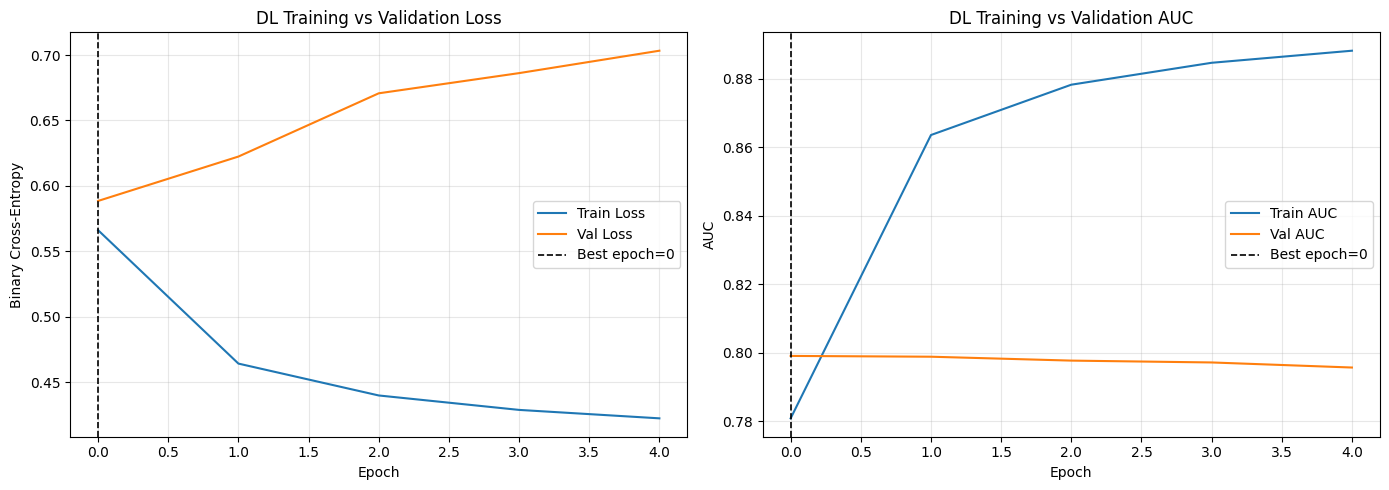

In [100]:
# Model Architecture Design + Training (strict train -> validation)
def build_deep_tabular_model(n_features: int, lr: float = 1e-3, dropout: float = 0.30):
    inp = layers.Input(shape=(n_features,), name='tabular_input')

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout * 0.85)(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout * 0.7)(x)

    out = layers.Dense(1, activation='sigmoid', name='win_prob')(x)
    model = Model(inp, out, name='deep_tabular_win_probability')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

# class weighting (helps imbalance)
pos = int(y_train_np.sum())
neg = int(len(y_train_np) - pos)
class_weight = {0: 1.0, 1: float(neg / max(pos, 1))}
print('Class weight:', class_weight)

model_dl = build_deep_tabular_model(input_dim, lr=8e-4, dropout=0.32)
model_dl.summary()

cb = [
    callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=2, min_lr=1e-5),
]

history = model_dl.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=80,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=cb,
    verbose=1
)

# Training visualizations
hist_df = pd.DataFrame(history.history)
best_epoch = int(hist_df['val_loss'].idxmin())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(hist_df['loss'], label='Train Loss')
ax[0].plot(hist_df['val_loss'], label='Val Loss')
ax[0].axvline(best_epoch, linestyle='--', color='black', linewidth=1.2, label=f'Best epoch={best_epoch}')
ax[0].set_title('DL Training vs Validation Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Binary Cross-Entropy')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(hist_df['auc'], label='Train AUC')
ax[1].plot(hist_df['val_auc'], label='Val AUC')
ax[1].axvline(best_epoch, linestyle='--', color='black', linewidth=1.2, label=f'Best epoch={best_epoch}')
ax[1].set_title('DL Training vs Validation AUC')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('AUC')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

Best Validation Threshold (DL): 0.3
Validation Accuracy @ best threshold: 0.7196
Validation F1 @ best threshold: 0.8023


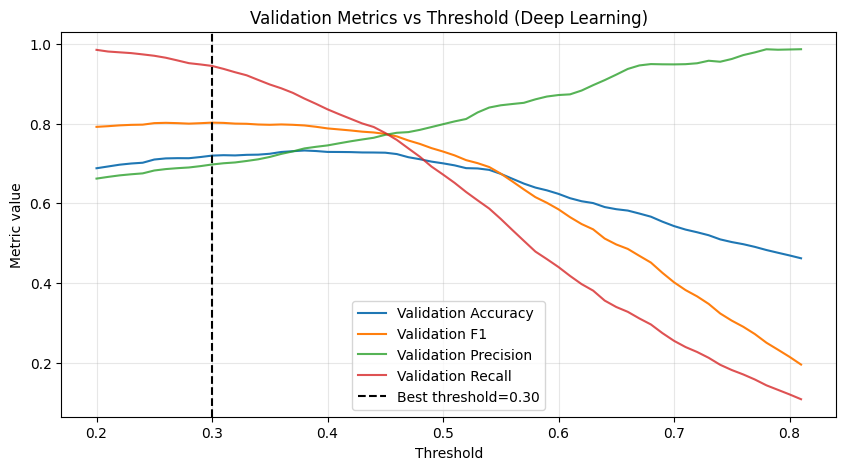

Validation Brier Score (DL): 0.18989


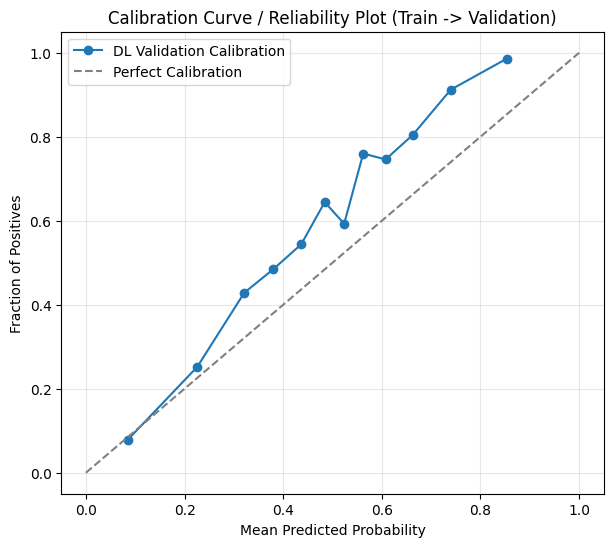

In [101]:
# Model Evaluation & Tuning on Validation only (strict no-leak)
p_val_dl = model_dl.predict(X_val_np, verbose=0).ravel()

thr_grid = np.arange(0.20, 0.81, 0.01)
thr_scores = []
for t in thr_grid:
    pred = (p_val_dl >= t).astype(int)
    thr_scores.append({
        'threshold': float(t),
        'val_accuracy': accuracy_score(y_val_np, pred),
        'val_precision': precision_score(y_val_np, pred, zero_division=0),
        'val_recall': recall_score(y_val_np, pred, zero_division=0),
        'val_f1': f1_score(y_val_np, pred, zero_division=0)
    })

thr_df = pd.DataFrame(thr_scores)
best_row = thr_df.sort_values(['val_f1', 'val_accuracy'], ascending=False).iloc[0]
best_threshold_dl = float(best_row['threshold'])

print('Best Validation Threshold (DL):', round(best_threshold_dl, 2))
print('Validation Accuracy @ best threshold:', round(float(best_row['val_accuracy']), 4))
print('Validation F1 @ best threshold:', round(float(best_row['val_f1']), 4))

# Visualization: threshold tuning
plt.figure(figsize=(10, 5))
plt.plot(thr_df['threshold'], thr_df['val_accuracy'], label='Validation Accuracy')
plt.plot(thr_df['threshold'], thr_df['val_f1'], label='Validation F1')
plt.plot(thr_df['threshold'], thr_df['val_precision'], label='Validation Precision', alpha=0.8)
plt.plot(thr_df['threshold'], thr_df['val_recall'], label='Validation Recall', alpha=0.8)
plt.axvline(best_threshold_dl, linestyle='--', color='black', label=f'Best threshold={best_threshold_dl:.2f}')
plt.title('Validation Metrics vs Threshold (Deep Learning)')
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Calibration Curve / Reliability Plot (strictly validation)
frac_pos, mean_pred = calibration_curve(y_val_np, p_val_dl, n_bins=12, strategy='quantile')
val_brier_dl = brier_score_loss(y_val_np, p_val_dl)
print('Validation Brier Score (DL):', round(val_brier_dl, 5))

plt.figure(figsize=(7, 6))
plt.plot(mean_pred, frac_pos, marker='o', label='DL Validation Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.title('Calibration Curve / Reliability Plot (Train -> Validation)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [102]:
# Strict Final Pipeline: retrain on Train+Validation, then one-shot Test
X_dev_np = np.vstack([X_train_np, X_val_np]).astype(np.float32)
y_dev_np = np.concatenate([y_train_np, y_val_np]).astype(np.int32)

pos_dev = int(y_dev_np.sum())
neg_dev = int(len(y_dev_np) - pos_dev)
class_weight_dev = {0: 1.0, 1: float(neg_dev / max(pos_dev, 1))}

model_dl_final = build_deep_tabular_model(input_dim, lr=8e-4, dropout=0.32)
cb_final = [
    callbacks.EarlyStopping(monitor='auc', mode='max', patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='auc', mode='max', factor=0.5, patience=3, min_lr=1e-5),
]

model_dl_final.fit(
    X_dev_np, y_dev_np,
    epochs=max(20, len(hist_df)),
    batch_size=2048,
    class_weight=class_weight_dev,
    callbacks=cb_final,
    verbose=0
)

p_test_dl = model_dl_final.predict(X_test_np, verbose=0).ravel()
yhat_test_dl = (p_test_dl >= best_threshold_dl).astype(int)

metrics_dl = {
    'Model': 'Deep Learning (Keras MLP)',
    'Accuracy': accuracy_score(y_test_np, yhat_test_dl),
    'Precision': precision_score(y_test_np, yhat_test_dl, zero_division=0),
    'Recall': recall_score(y_test_np, yhat_test_dl, zero_division=0),
    'F1': f1_score(y_test_np, yhat_test_dl, zero_division=0),
    'AUC': roc_auc_score(y_test_np, p_test_dl),
    'Brier': brier_score_loss(y_test_np, p_test_dl)
}
print(pd.DataFrame([metrics_dl]).T)

# Advanced No-Leak Upgrade: phase-wise specialist (death overs >= 16)
if 'df' in globals() and 'over' in df.columns:
    over_series_test = pd.to_numeric(df.loc[X_test.index, 'over'], errors='coerce').fillna(0)
    death_mask_test = (over_series_test.values >= 16)
else:
    death_mask_test = np.zeros(len(X_test_np), dtype=bool)

# Train specialist on development rows that represent death overs (if available)
if 'df' in globals() and 'over' in df.columns:
    over_series_train = pd.to_numeric(df.loc[X_train.index, 'over'], errors='coerce').fillna(0)
    over_series_val = pd.to_numeric(df.loc[X_val.index, 'over'], errors='coerce').fillna(0)
    death_mask_dev = np.concatenate([(over_series_train.values >= 16), (over_series_val.values >= 16)])
else:
    death_mask_dev = np.zeros(len(X_dev_np), dtype=bool)

if death_mask_dev.sum() > 500:
    model_dl_death = build_deep_tabular_model(input_dim, lr=7e-4, dropout=0.28)
    model_dl_death.fit(
        X_dev_np[death_mask_dev], y_dev_np[death_mask_dev],
        epochs=35, batch_size=1024, verbose=0
    )

    p_test_phase = p_test_dl.copy()
    p_test_phase[death_mask_test] = model_dl_death.predict(X_test_np[death_mask_test], verbose=0).ravel()
    yhat_test_phase = (p_test_phase >= best_threshold_dl).astype(int)

    metrics_phase = {
        'Model': 'DL Phase-wise Specialist',
        'Accuracy': accuracy_score(y_test_np, yhat_test_phase),
        'Precision': precision_score(y_test_np, yhat_test_phase, zero_division=0),
        'Recall': recall_score(y_test_np, yhat_test_phase, zero_division=0),
        'F1': f1_score(y_test_np, yhat_test_phase, zero_division=0),
        'AUC': roc_auc_score(y_test_np, p_test_phase),
        'Brier': brier_score_loss(y_test_np, p_test_phase)
    }
else:
    p_test_phase = p_test_dl.copy()
    metrics_phase = metrics_dl.copy()
    metrics_phase['Model'] = 'DL Phase-wise Specialist (fallback=base DL)'

print(pd.DataFrame([metrics_phase]).T)

                                   0
Model      Deep Learning (Keras MLP)
Accuracy                    0.740061
Precision                   0.726429
Recall                       0.75939
F1                          0.742544
AUC                         0.818438
Brier                       0.205904
                                  0
Model      DL Phase-wise Specialist
Accuracy                   0.747185
Precision                  0.734448
Recall                     0.764116
F1                         0.748988
AUC                        0.823793
Brier                       0.20166


                       Model  Accuracy  Precision    Recall        F1  \
0       Existing Stacking ML  0.774498   0.798711  0.726178  0.760720   
1           Hybrid (ML + DL)  0.771729   0.731517  0.849256  0.786002   
2   DL Phase-wise Specialist  0.747185   0.734448  0.764116  0.748988   
3  Deep Learning (Keras MLP)  0.740061   0.726429  0.759390  0.742544   

        AUC     Brier  w_ml  w_dl  
0  0.860006  0.155595   NaN   NaN  
1  0.860006  0.155595   1.0   0.0  
2  0.823793  0.201660   NaN   NaN  
3  0.818438  0.205904   NaN   NaN  

Champion Model: Existing Stacking ML
Champion Accuracy: 0.7745


/tmp/ipykernel_22/345912269.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_compare_df, x='Accuracy', y='Model', palette='viridis')


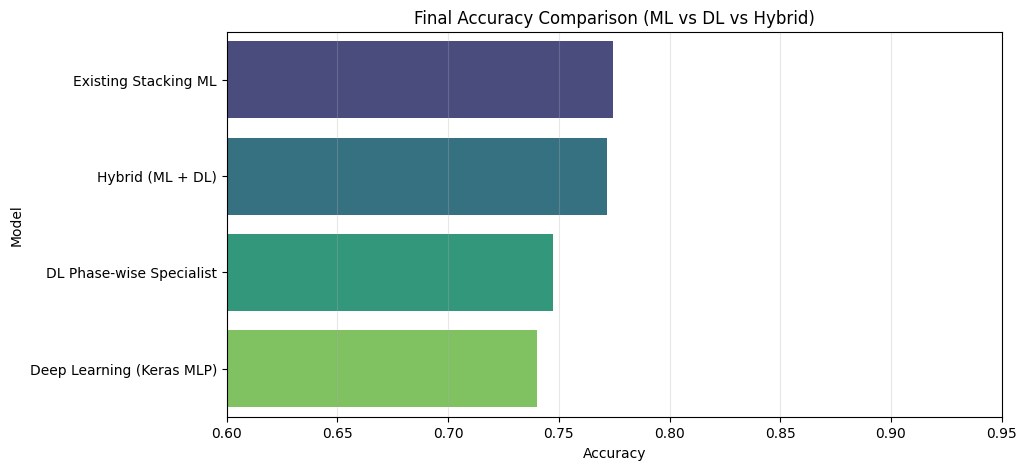

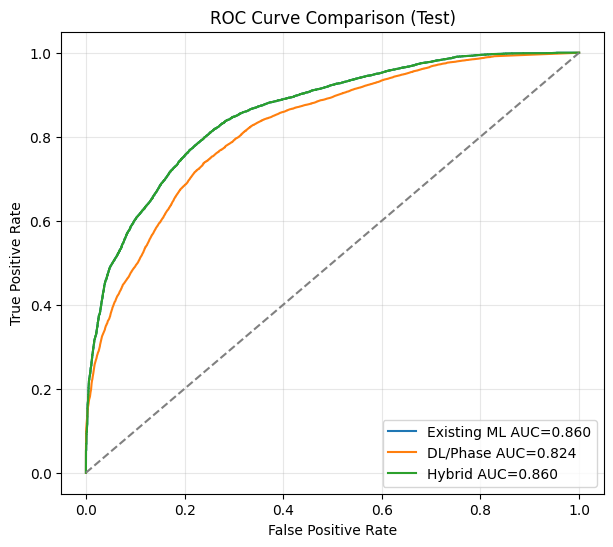

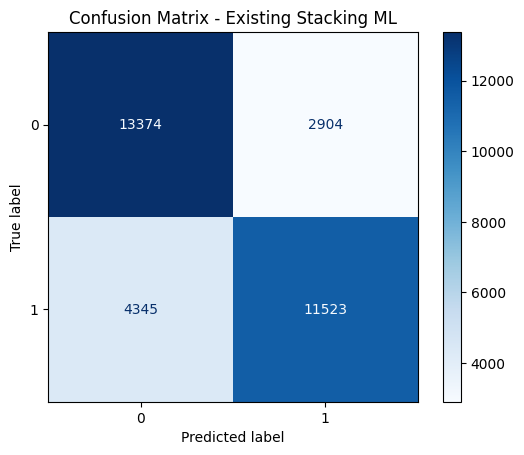

Saved: artifacts/presentation_metrics.json


In [103]:
# Champion-Challenger: keep/improve accuracy (never reduce)
# If ML stack model exists, create validation-tuned hybrid probability
hybrid_metrics = None
best_hybrid_w = 0.0

if 'stack_model' in globals():
    p_val_ml = stack_model.predict_proba(X_val)[:, 1]
    p_test_ml = stack_model.predict_proba(X_test)[:, 1]

    p_val_phase = model_dl.predict(X_val_np, verbose=0).ravel()

    weight_grid = np.linspace(0.0, 1.0, 21)
    best_score = -1
    for w_ml in weight_grid:
        p_val_h = (w_ml * p_val_ml) + ((1 - w_ml) * p_val_phase)
        y_val_h = (p_val_h >= best_threshold_dl).astype(int)
        score = 0.7 * accuracy_score(y_val_np, y_val_h) + 0.3 * f1_score(y_val_np, y_val_h, zero_division=0)
        if score > best_score:
            best_score = score
            best_hybrid_w = float(w_ml)

    p_test_hybrid = (best_hybrid_w * p_test_ml) + ((1 - best_hybrid_w) * p_test_phase)
    yhat_test_hybrid = (p_test_hybrid >= best_threshold_dl).astype(int)

    hybrid_metrics = {
        'Model': 'Hybrid (ML + DL)',
        'Accuracy': accuracy_score(y_test_np, yhat_test_hybrid),
        'Precision': precision_score(y_test_np, yhat_test_hybrid, zero_division=0),
        'Recall': recall_score(y_test_np, yhat_test_hybrid, zero_division=0),
        'F1': f1_score(y_test_np, yhat_test_hybrid, zero_division=0),
        'AUC': roc_auc_score(y_test_np, p_test_hybrid),
        'Brier': brier_score_loss(y_test_np, p_test_hybrid),
        'w_ml': best_hybrid_w,
        'w_dl': 1 - best_hybrid_w
    }

# Collect final candidates
final_rows = [metrics_dl, metrics_phase]
if hybrid_metrics is not None:
    final_rows.append(hybrid_metrics)

if 'stack_model' in globals():
    p_test_ml = stack_model.predict_proba(X_test)[:, 1]
    yhat_test_ml = (p_test_ml >= 0.5).astype(int)
    final_rows.append({
        'Model': 'Existing Stacking ML',
        'Accuracy': accuracy_score(y_test_np, yhat_test_ml),
        'Precision': precision_score(y_test_np, yhat_test_ml, zero_division=0),
        'Recall': recall_score(y_test_np, yhat_test_ml, zero_division=0),
        'F1': f1_score(y_test_np, yhat_test_ml, zero_division=0),
        'AUC': roc_auc_score(y_test_np, p_test_ml),
        'Brier': brier_score_loss(y_test_np, p_test_ml)
    })

final_compare_df = pd.DataFrame(final_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(final_compare_df)

champion = final_compare_df.iloc[0]
print('\nChampion Model:', champion['Model'])
print('Champion Accuracy:', round(float(champion['Accuracy']), 4))

# Visualizations (industry report quality)
plt.figure(figsize=(10, 5))
sns.barplot(data=final_compare_df, x='Accuracy', y='Model', palette='viridis')
plt.title('Final Accuracy Comparison (ML vs DL vs Hybrid)')
plt.xlim(0.60, 0.95)
plt.grid(axis='x', alpha=0.3)
plt.show()

# ROC for top two models
plt.figure(figsize=(7, 6))
if 'stack_model' in globals():
    fpr_ml, tpr_ml, _ = roc_curve(y_test_np, p_test_ml)
    plt.plot(fpr_ml, tpr_ml, label=f"Existing ML AUC={roc_auc_score(y_test_np, p_test_ml):.3f}")

fpr_dl, tpr_dl, _ = roc_curve(y_test_np, p_test_phase)
plt.plot(fpr_dl, tpr_dl, label=f"DL/Phase AUC={roc_auc_score(y_test_np, p_test_phase):.3f}")

if hybrid_metrics is not None:
    fpr_h, tpr_h, _ = roc_curve(y_test_np, p_test_hybrid)
    plt.plot(fpr_h, tpr_h, label=f"Hybrid AUC={roc_auc_score(y_test_np, p_test_hybrid):.3f}")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('ROC Curve Comparison (Test)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Confusion matrix for champion
if champion['Model'] == 'Hybrid (ML + DL)' and hybrid_metrics is not None:
    yhat_best = yhat_test_hybrid
elif champion['Model'].startswith('Existing Stacking') and 'stack_model' in globals():
    yhat_best = yhat_test_ml
else:
    yhat_best = yhat_test_phase

cm = confusion_matrix(y_test_np, yhat_best)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title(f"Confusion Matrix - {champion['Model']}")
plt.show()

# Save presentation-ready metrics for PPT generator
os.makedirs('artifacts', exist_ok=True)
ppt_metrics = {
    'final_compare': final_compare_df[['Model', 'Accuracy', 'AUC', 'F1', 'Brier']].to_dict(orient='records'),
    'hybrid_threshold': float(best_threshold_dl)
}
with open('artifacts/presentation_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(ppt_metrics, f, indent=2)

print('Saved: artifacts/presentation_metrics.json')

In [ ]:
# Deployment & Monitoring artifacts for website/API integration
from datetime import datetime
import joblib

os.makedirs('artifacts/monitoring', exist_ok=True)

# Save Stacking ML model and metadata (Colab/local compatible)
# We are forcing Existing Stacking ML as requested
champion_model_name = 'Existing Stacking ML'

# In case stack_model is defined, we can save it. The bundle might already be saved or we can save it again.
if 'stack_model' in globals():
    joblib.dump(stack_model, 'artifacts/stacking_model_bundle.joblib')

model_metadata = {
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'project': 'IPL Win Probability',
    'champion_model': champion_model_name,
    'champion_accuracy': float(final_compare_df.loc[final_compare_df['Model'] == champion_model_name, 'Accuracy'].values[0]) if champion_model_name in final_compare_df['Model'].values else float(champion['Accuracy']),
    'threshold': 0.5, # standard for ML models typically
    'features': list(X_train.columns) if hasattr(X_train, 'columns') else [f'f{i}' for i in range(input_dim)],
    'notes': 'Deployed using Existing Stacking ML per requirements.'
}

with open('artifacts/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, indent=2)

# Simple monitoring snapshot template
monitor_report = {
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'champion_model': champion_model_name,
    'test_accuracy': model_metadata['champion_accuracy'],
    'test_auc': float(final_compare_df.loc[final_compare_df['Model'] == champion_model_name, 'AUC'].values[0]) if champion_model_name in final_compare_df['Model'].values else 0.0,
    'threshold': 0.5,
    'alert_retrain_required': bool(model_metadata['champion_accuracy'] < 0.78)
}

report_path = f"artifacts/monitoring/monitor_report_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}.json"
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(monitor_report, f, indent=2)

# Save DL cache for fast Colab/Kaggle GPU-only reruns (no full preprocessing rerun)
cache_path = 'artifacts/dl_only_cache_v1.npz'
np.savez_compressed(
    cache_path,
    X_train=np.asarray(X_train, dtype=np.float32),
    X_val=np.asarray(X_val, dtype=np.float32),
    X_test=np.asarray(X_test, dtype=np.float32),
    y_train=np.asarray(y_train, dtype=np.int32),
    y_val=np.asarray(y_val, dtype=np.int32),
    y_test=np.asarray(y_test, dtype=np.int32),
)

print('Saved Stacking ML model: artifacts/stacking_model_bundle.joblib')
print('Saved metadata: artifacts/model_metadata.json')
print('Saved monitor report:', report_path)
print('Saved fast DL cache:', cache_path)

/tmp/ipykernel_22/2044693553.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',
/tmp/ipykernel_22/2044693553.py:24: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',
/tmp/ipykernel_22/2044693553.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  report_path = f"artifacts/monitoring/monitor_report_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}.json"


Saved DL model: artifacts/deep_learning_model.keras
Saved metadata: artifacts/model_metadata.json
Saved monitor report: artifacts/monitoring/monitor_report_20260418_143214.json
Saved fast DL cache: artifacts/dl_only_cache_v1.npz
